In [8]:
import sys
from pathlib import Path

# Add workspace root to path so we can import infraScan
workspace_root = Path("/Users/laura/Desktop/infraScan_lkuehner")
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

print(f"✓ Path setup: {sys.path[0]}")

✓ Path setup: /Users/laura/Desktop/infraScan_lkuehner


In [9]:
import matplotlib

if not hasattr(matplotlib.rcParams, "_get"):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__


# Road vs Rail: raw and integrated comparison

This notebook is meant as a working analysis layer on top of the current Road and Rail outputs.

It does four things:
1. loads the newer Road run from the first available configured costs directory
2. loads Rail from the first available configured costs directory
3. builds raw and integrated values per parameter, close to the logic sketched in `scoring_registry.py`
4. compares scenario spread and ranks developments with a Nutzen/Kosten-Faktor (BCR)

Important note:
- the raw values are still model-native outputs and therefore not always directly cross-mode comparable
- the integrated values are the cleaner basis for road vs rail comparison
- for Road maintenance, the notebook falls back to a derivation from `TTS - net benefit - construction - externalities` if the current `maintenance.gpkg` cannot be opened directly


In [10]:
from pathlib import Path
import math
import re
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from infraScan.infraScanIntegrated import common_cost_parameters
from infraScan.infraScanIntegrated import scoring_registry as registry
from infraScan.infraScanRoad import cost_parameters as road_cost_parameters

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def first_existing_path(candidates: list[Path]) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("None of the configured data paths exists:\n" + "\n".join(str(path) for path in candidates))


ROAD_COSTS_DIR = first_existing_path([
    Path("/Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/costs_trust_xi_all10sce"),
    workspace_root / "data" / "infraScanRoad" / "costs_trust_xi_all10sce",
])
RAIL_COSTS_DIR = first_existing_path([
    Path("/Volumes/WD_Windows/MSc_Thesis/data/infraScanRail/costs"),
    workspace_root / "data" / "infraScanRail" / "costs",
])
OUTPUT_DIR = Path("/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanIntegrated/notebook_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Road costs dir:", ROAD_COSTS_DIR)
print("Rail costs dir:", RAIL_COSTS_DIR)

ROAD_MAINTENANCE_CANDIDATES = [
    ROAD_COSTS_DIR / "maintenance.gpkg",
]

ROAD_TTS_CSV = ROAD_COSTS_DIR / "traveltime_savings_od.csv"
ROAD_TOTALS_CSV = ROAD_COSTS_DIR / "total_costs_od.csv"
ROAD_CONSTRUCTION_CANDIDATES = [
    ROAD_COSTS_DIR / "total_costs_od.gpkg",
]
ROAD_EXTERNALITIES_GPKG = ROAD_COSTS_DIR / "externalities.gpkg"
ROAD_NOISE_GPKG = ROAD_COSTS_DIR / "noise.gpkg"

RAIL_CONSTRUCTION_CSV = RAIL_COSTS_DIR / "construction_cost.csv"
RAIL_TOTAL_COSTS_CSV = RAIL_COSTS_DIR / "total_costs.csv"
RAIL_TTS_CSV = RAIL_COSTS_DIR / "traveltime_savings.csv"


Road costs dir: /Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/costs_trust_xi_all10sce
Rail costs dir: /Volumes/WD_Windows/MSc_Thesis/data/infraScanRail/costs


In [11]:
import importlib
importlib.reload(registry)

<module 'infraScan.infraScanIntegrated.scoring_registry' from '/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanIntegrated/scoring_registry.py'>

In [12]:
def read_gpkg_table(path: Path, table: str | None = None, columns: list[str] | None = None) -> pd.DataFrame:
    con = sqlite3.connect(f"file:{path}?mode=ro", uri=True)
    try:
        if table is None:
            contents = pd.read_sql("SELECT table_name, data_type FROM gpkg_contents", con)
            table = contents.loc[contents["data_type"].isin(["features", "attributes"]), "table_name"].iloc[0]
        if columns is None:
            query = f"SELECT * FROM '{table}'"
        else:
            query = f"SELECT {', '.join(columns)} FROM '{table}'"
        return pd.read_sql(query, con)
    finally:
        con.close()


def try_read_first(paths: list[Path], columns: list[str]) -> tuple[pd.DataFrame | None, Path | None]:
    for path in paths:
        try:
            return read_gpkg_table(path, columns=columns), path
        except Exception:
            continue
    return None, None


def get_table_columns(path: Path, table: str | None = None) -> list[str]:
    con = sqlite3.connect(f"file:{path}?mode=ro", uri=True)
    try:
        if table is None:
            contents = pd.read_sql("SELECT table_name, data_type FROM gpkg_contents", con)
            table = contents.loc[contents["data_type"].isin(["features", "attributes"]), "table_name"].iloc[0]
        return pd.read_sql(f"PRAGMA table_info('{table}')", con)["name"].tolist()
    finally:
        con.close()


def normalize_development(values: pd.Series) -> pd.Series:
    normalized = values.astype(str)
    normalized = normalized.str.replace("Development_", "", regex=False)
    normalized = normalized.str.replace(r"\.0$", "", regex=True)
    return normalized


def scenario_number(scenario: str) -> int:
    match = re.search(r"(\d+)$", str(scenario))
    return int(match.group(1)) if match else -1


def sort_scenarios(scenarios: list[str]) -> list[str]:
    return sorted(scenarios, key=scenario_number)


def melt_scenario_columns(df: pd.DataFrame, id_col: str, prefix: str, value_name: str) -> pd.DataFrame:
    value_cols = [col for col in df.columns if col.startswith(prefix)]
    melted = df[[id_col] + value_cols].melt(id_vars=id_col, var_name="scenario", value_name=value_name)
    melted["scenario"] = melted["scenario"].str.removeprefix(prefix)
    melted = melted.rename(columns={id_col: "development"})
    melted["development"] = normalize_development(melted["development"])
    return melted


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return np.where(np.abs(denominator) > 1e-9, numerator / denominator, np.nan)


def score_result_to_frame(
    result_df: pd.DataFrame,
    score_id: str,
    standalone_name: str,
    integrated_name: str,
) -> pd.DataFrame:
    out = result_df.loc[result_df["score_id"] == score_id, ["development", "scenario", "standalone_value", "integrated_value"]].copy()
    out = out.rename(columns={"standalone_value": standalone_name, "integrated_value": integrated_name})
    out["development"] = normalize_development(out["development"])
    out["scenario"] = out["scenario"].astype(str)
    return out


print("Road open-highway CRF:", registry.capital_recovery_factor(common_cost_parameters.discount_rate, road_cost_parameters.openhighway_lifetime))
print("Road maintenance dyn factor:", registry.dynamization_factor(common_cost_parameters.road_maintenance_operating_cost_growth, common_cost_parameters.appraisal_years, common_cost_parameters.discount_rate))
print("TTS dyn factor:", registry.dynamization_factor(common_cost_parameters.real_wage_growth, common_cost_parameters.appraisal_years, common_cost_parameters.discount_rate))


Road open-highway CRF: 0.02876796582580632
Road maintenance dyn factor: 1.1808096937801478
TTS dyn factor: 1.1138450223459064


In [13]:
def load_road_frame() -> tuple[pd.DataFrame, dict]:
    construction_columns = ["ID_new", "cost_path", "cost_bridge", "cost_tunnel", "building_costs"]
    construction_path = ROAD_CONSTRUCTION_CANDIDATES[0]
    available_construction_columns = get_table_columns(construction_path)
    if "cost_ramp" in available_construction_columns:
        construction_columns.append("cost_ramp")
    construction = read_gpkg_table(construction_path, columns=construction_columns)
    if construction is None:
        raise FileNotFoundError(f"Could not read a road construction source from {ROAD_CONSTRUCTION_CANDIDATES}")
    for col in ["cost_path", "cost_bridge", "cost_tunnel", "cost_ramp", "building_costs"]:
        if col in construction.columns:
            construction[col] = pd.to_numeric(construction[col], errors="coerce").abs()
    construction["cost_open_highway"] = construction["cost_path"]
    if "cost_ramp" not in construction.columns:
        construction["cost_ramp"] = (
            construction["building_costs"]
            - construction["cost_path"]
            - construction["cost_bridge"]
            - construction["cost_tunnel"]
        ).clip(lower=0)
    construction_for_merge = construction.rename(columns={"ID_new": "development"}).copy()
    construction_for_merge["development"] = normalize_development(construction_for_merge["development"])

    externalities = read_gpkg_table(
        ROAD_EXTERNALITIES_GPKG,
        columns=["ID_new", "climate_cost", "land_realloc", "nature"],
    ).rename(columns={"ID_new": "development"})
    externalities["development"] = normalize_development(externalities["development"])

    noise = read_gpkg_table(
        ROAD_NOISE_GPKG,
        columns=["ID_new", "noise_s1"],
    ).rename(columns={"ID_new": "development"})
    noise["development"] = normalize_development(noise["development"])

    components = construction_for_merge.merge(externalities, on="development", how="left").merge(noise, on="development", how="left")
    components["externalities_raw"] = (
        components[["climate_cost", "land_realloc", "nature", "noise_s1"]].fillna(0).sum(axis=1)
    )

    road_tt_wide = pd.read_csv(ROAD_TTS_CSV)
    if "ID_new" in road_tt_wide.columns and "development" not in road_tt_wide.columns:
        road_tt_wide = road_tt_wide.rename(columns={"ID_new": "development"})
    road_tt_wide["development"] = normalize_development(road_tt_wide["development"])

    road_totals_wide = pd.read_csv(ROAD_TOTALS_CSV)
    road_tt_scenarios = {col.removeprefix("tt_") for col in road_tt_wide.columns if col.startswith("tt_")}
    road_total_scenarios = {col.removeprefix("total_") for col in road_totals_wide.columns if col.startswith("total_scenario_")}
    scenarios = sort_scenarios(list(road_tt_scenarios & road_total_scenarios))

    tt_long = melt_scenario_columns(road_tt_wide, "development", "tt_", "tts_raw_input")
    tt_long = tt_long[tt_long["scenario"].isin(scenarios)].copy()

    nb_cols = ["ID_new"] + [f"total_{scenario}" for scenario in scenarios]
    nb_long = melt_scenario_columns(road_totals_wide[nb_cols], "ID_new", "total_", "net_benefit_raw")

    road = tt_long.merge(nb_long, on=["development", "scenario"], how="left")
    road = road.merge(components[["development", "building_costs", "externalities_raw"]], on="development", how="left")

    maintenance_path = next((path for path in ROAD_MAINTENANCE_CANDIDATES if path.exists()), None)
    maintenance_df = None
    notes = {
        "road_construction_source": str(construction_path) if construction_path is not None else None,
        "road_maintenance_source": None,
        "road_maintenance_derived": False,
        "road_scenarios": scenarios,
    }

    if maintenance_path is not None:
        maintenance_columns = ["ID_new", "maintenance"]
        available_columns = get_table_columns(maintenance_path)
        if "maintenance_annual" in available_columns:
            maintenance_columns.append("maintenance_annual")
        maintenance_df = read_gpkg_table(maintenance_path, columns=maintenance_columns)
        notes["road_maintenance_source"] = str(maintenance_path)

    construction_scores = score_result_to_frame(
        registry.build_road_construction_result_df(construction, scenarios),
        "road_construction_cost",
        "construction_raw",
        "construction_integrated",
    )
    road = road.merge(construction_scores, on=["development", "scenario"], how="left")

    tts_scores = score_result_to_frame(
        registry.build_road_tts_result_df(road_tt_wide, scenarios),
        "road_tts_cost",
        "tts_raw",
        "tts_integrated",
    )
    road = road.merge(tts_scores, on=["development", "scenario"], how="left")

    derived_maintenance = (
        road["tts_raw"] - road["construction_raw"] - road["externalities_raw"] - road["net_benefit_raw"]
    )
    maintenance_from_balance = (
        pd.DataFrame({"development": road["development"], "maintenance_derived": derived_maintenance})
        .groupby("development", as_index=False)["maintenance_derived"]
        .median()
    )
    road = road.merge(maintenance_from_balance, on="development", how="left")

    if maintenance_df is not None:
        maintenance_df = maintenance_df.rename(columns={"ID_new": "development"})
        maintenance_df["development"] = normalize_development(maintenance_df["development"])
        if "maintenance_annual" not in maintenance_df.columns:
            maintenance_df = maintenance_df.merge(maintenance_from_balance, on="development", how="left")
            maintenance_df["maintenance_annual"] = maintenance_df["maintenance_derived"]
            notes["road_maintenance_derived"] = True
        else:
            maintenance_df = maintenance_df.merge(maintenance_from_balance, on="development", how="left")
            deviation = (maintenance_df["maintenance_annual"] - maintenance_df["maintenance_derived"]).abs().median()
            notes["road_maintenance_balance_check_abs_median"] = float(deviation)
    else:
        maintenance_df = maintenance_from_balance.rename(columns={"development": "ID_new", "maintenance_derived": "maintenance_annual"})
        maintenance_df["maintenance"] = maintenance_df["maintenance_annual"]
        notes["road_maintenance_derived"] = True

    maintenance_registry_input = maintenance_df[[col for col in ["ID_new", "maintenance_annual"] if col in maintenance_df.columns]].copy()
    if "ID_new" not in maintenance_registry_input.columns:
        maintenance_registry_input = maintenance_df.rename(columns={"development": "ID_new"})[["ID_new", "maintenance_annual"]].copy()
    maintenance_debug = maintenance_df.rename(columns={"ID_new": "development"}).copy() if "ID_new" in maintenance_df.columns else maintenance_df.copy()
    if "development" in maintenance_debug.columns:
        maintenance_debug["development"] = normalize_development(maintenance_debug["development"])
    road = road.merge(
        maintenance_debug[[col for col in ["development", "maintenance", "maintenance_annual"] if col in maintenance_debug.columns]],
        on="development",
        how="left",
    )

    maintenance_scores = score_result_to_frame(
        registry.build_road_maint_result_df(maintenance_registry_input, scenarios),
        "road_maint_cost",
        "maintenance_raw",
        "maintenance_integrated",
    )
    road = road.merge(maintenance_scores, on=["development", "scenario"], how="left")

    road["operation_raw"] = 0.0
    road["operation_integrated"] = 0.0
    road["cost_base_raw"] = road[["construction_raw", "maintenance_raw", "operation_raw"]].sum(axis=1)
    road["cost_base_integrated"] = road[["construction_integrated", "maintenance_integrated", "operation_integrated"]].sum(axis=1)
    road["bcr_raw"] = safe_ratio(road["tts_raw"], road["cost_base_raw"])
    road["bcr_integrated"] = safe_ratio(road["tts_integrated"], road["cost_base_integrated"])
    road["net_benefit_integrated"] = road["tts_integrated"] - road["cost_base_integrated"]
    road["mode"] = "Road"

    return road, notes


def load_rail_frame(selected_scenarios: list[str]) -> tuple[pd.DataFrame, dict]:
    construction_raw = pd.read_csv(RAIL_CONSTRUCTION_CSV)
    construction = construction_raw.rename(columns={"Development": "development"}).copy()
    construction["development"] = normalize_development(construction["development"])

    rail_total = pd.read_csv(RAIL_TOTAL_COSTS_CSV)
    rail_total["development"] = normalize_development(rail_total["development"])

    rail_tts = pd.read_csv(RAIL_TTS_CSV)
    rail_tts["development"] = normalize_development(rail_tts["development"])
    rail_tts["year"] = pd.to_numeric(rail_tts["year"], errors="coerce")
    available_years = sorted(rail_tts["year"].dropna().astype(int).unique().tolist())
    rail_year = common_cost_parameters.prognosis_year if common_cost_parameters.prognosis_year in available_years else max(available_years)
    rail_tts = rail_tts[(rail_tts["year"] == rail_year) & (rail_tts["scenario"].isin(selected_scenarios))].copy()

    frames = []
    for scenario in selected_scenarios:
        suffix = scenario.split("_")[-1]
        frame = rail_total[["development"]].copy()
        frame["scenario"] = scenario
        frame["net_benefit_reported"] = rail_total[f"Net Benefit Scenario {suffix} [in Mio. CHF]"] * 1_000_000
        frame["bcr_reported"] = rail_total[f"cba_ratio_scenario_{suffix}"]
        frames.append(frame)
    rail_nb = pd.concat(frames, ignore_index=True)

    rail = rail_tts.merge(rail_nb, on=["development", "scenario"], how="left")

    construction_registry_input = construction_raw.rename(columns={
        "Development": "ID_new",
        "TotalConstructionCost": "building_costs",
    }).copy()

    construction_scores = score_result_to_frame(
        registry.build_rail_construction_result_df(construction_registry_input, selected_scenarios),
        "rail_construction_cost",
        "construction_raw",
        "construction_integrated",
    )
    rail = rail.merge(construction_scores, on=["development", "scenario"], how="left")

    rail_static_registry = construction_raw.rename(columns={"Development": "ID_new"}).copy()
    maintenance_scores = score_result_to_frame(
        registry.build_rail_maint_result_df(rail_static_registry, selected_scenarios),
        "rail_maint_cost",
        "maintenance_raw",
        "maintenance_integrated",
    )
    operation_scores = score_result_to_frame(
        registry.build_rail_operation_result_df(rail_static_registry, selected_scenarios),
        "rail_operation_cost",
        "operation_raw",
        "operation_integrated",
    )
    rail = rail.merge(maintenance_scores, on=["development", "scenario"], how="left")
    rail = rail.merge(operation_scores, on=["development", "scenario"], how="left")

    rail_tts_registry_input = rail_tts.copy()
    rail_tts_registry_input["year"] = common_cost_parameters.prognosis_year
    tts_scores = score_result_to_frame(
        registry.build_rail_tts_result_df(rail_tts_registry_input),
        "rail_tts_cost",
        "tts_raw",
        "tts_integrated",
    )
    rail = rail.merge(tts_scores, on=["development", "scenario"], how="left")

    rail["externalities_raw"] = np.nan
    rail["cost_base_raw"] = rail[["construction_raw", "maintenance_raw", "operation_raw"]].sum(axis=1)
    rail["cost_base_integrated"] = rail[["construction_integrated", "maintenance_integrated", "operation_integrated"]].sum(axis=1)
    rail["bcr_raw"] = safe_ratio(rail["tts_raw"], rail["cost_base_raw"])
    rail["bcr_integrated"] = safe_ratio(rail["tts_integrated"], rail["cost_base_integrated"])
    rail["net_benefit_integrated"] = rail["tts_integrated"] - rail["cost_base_integrated"]
    rail["mode"] = "Rail"

    notes = {
        "rail_year_used_for_tts": rail_year,
        "rail_scenarios": selected_scenarios,
    }
    return rail, notes


road_df, road_notes = load_road_frame()
rail_df, rail_notes = load_rail_frame(road_notes["road_scenarios"])

combined = pd.concat([road_df, rail_df], ignore_index=True, sort=False)
print("Road shape:", road_df.shape)
print("Rail shape:", rail_df.shape)
print("Shared scenarios:", len(road_notes["road_scenarios"]), road_notes["road_scenarios"])
print("Road notes:", road_notes)
print("Rail notes:", rail_notes)


Road shape: (1380, 23)
Rail shape: (390, 24)
Shared scenarios: 10 ['scenario_19', 'scenario_26', 'scenario_44', 'scenario_64', 'scenario_70', 'scenario_75', 'scenario_78', 'scenario_89', 'scenario_96', 'scenario_100']
Road notes: {'road_construction_source': '/Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/costs_trust_xi_all10sce/total_costs_od.gpkg', 'road_maintenance_source': '/Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/costs_trust_xi_all10sce/maintenance.gpkg', 'road_maintenance_derived': False, 'road_scenarios': ['scenario_19', 'scenario_26', 'scenario_44', 'scenario_64', 'scenario_70', 'scenario_75', 'scenario_78', 'scenario_89', 'scenario_96', 'scenario_100'], 'road_maintenance_balance_check_abs_median': 122776927.74584155}
Rail notes: {'rail_year_used_for_tts': 2050, 'rail_scenarios': ['scenario_19', 'scenario_26', 'scenario_44', 'scenario_64', 'scenario_70', 'scenario_75', 'scenario_78', 'scenario_89', 'scenario_96', 'scenario_100']}


In [14]:
def build_score_long(df: pd.DataFrame, include_externalities: bool = True) -> pd.DataFrame:
    score_map = {
        "construction": ("construction_raw", "construction_integrated"),
        "maintenance": ("maintenance_raw", "maintenance_integrated"),
        "tts": ("tts_raw", "tts_integrated"),
        "operation": ("operation_raw", "operation_integrated"),
    }
    frames = []
    for score_id, (raw_col, integrated_col) in score_map.items():
        tmp = df[["mode", "development", "scenario", raw_col, integrated_col]].copy()
        tmp = tmp.rename(columns={raw_col: "standalone_value", integrated_col: "integrated_value"})
        tmp["score_id"] = score_id
        frames.append(tmp)
    if include_externalities and "externalities_raw" in df.columns:
        tmp = df[["mode", "development", "scenario", "externalities_raw"]].copy()
        tmp = tmp.rename(columns={"externalities_raw": "standalone_value"})
        tmp["integrated_value"] = np.nan
        tmp["score_id"] = "externalities"
        frames.append(tmp)
    score_long = pd.concat(frames, ignore_index=True)
    return score_long[["mode", "development", "scenario", "score_id", "standalone_value", "integrated_value"]]


score_long = build_score_long(combined)
score_summary = (
    score_long.groupby(["mode", "score_id"], as_index=False)[["standalone_value", "integrated_value"]]
    .mean(numeric_only=True)
)
score_summary


,mode,score_id,standalone_value,integrated_value
0,Rail,construction,"47,254,333.33","1,375,467.82"
1,Rail,externalities,NaN,NaN
2,Rail,maintenance,"990,436.42","1,044,910.43"
3,Rail,operation,"7,015,521.33","7,401,375.00"
4,Rail,tts,"3,714,704.84","4,137,605.50"
5,Road,construction,"532,201,882.01","16,196,569.36"
6,Road,externalities,"623,296,019.47",NaN
7,Road,maintenance,"6,997,582.94","8,262,813.77"
8,Road,operation,0.00,0.00
9,Road,tts,"-44,739,047.14","-49,832,364.97"


In [15]:
spread_stats = (
    combined.groupby(["mode", "development"], as_index=False)
    .agg(
        scenarios=("scenario", "nunique"),
        mean_bcr_integrated=("bcr_integrated", "mean"),
        std_bcr_integrated=("bcr_integrated", "std"),
        min_bcr_integrated=("bcr_integrated", "min"),
        max_bcr_integrated=("bcr_integrated", "max"),
        mean_nb_integrated=("net_benefit_integrated", "mean"),
        std_nb_integrated=("net_benefit_integrated", "std"),
        viable_scenarios_integrated=("net_benefit_integrated", lambda values: int((values > 0).sum())),
    )
    .sort_values(["mode", "mean_bcr_integrated"], ascending=[True, False])
)

top10_developments = spread_stats.groupby("mode", group_keys=False).head(10)
top5_developments = spread_stats.groupby("mode", group_keys=False).head(5)
top10_scenarios = combined.sort_values(["mode", "bcr_integrated"], ascending=[True, False]).groupby("mode", group_keys=False).head(10)

display(top5_developments)
display(top10_scenarios[["mode", "development", "scenario", "bcr_integrated", "net_benefit_integrated"]])


,mode,development,scenarios,mean_bcr_integrated,std_bcr_integrated,min_bcr_integrated,max_bcr_integrated,mean_nb_integrated,std_nb_integrated,viable_scenarios_integrated
1,Rail,100001,10,7.26,2.19,4.18,10.96,"9,711,035.81","3,403,089.58",10
0,Rail,100000,10,2.98,0.90,1.71,4.49,"2,362,227.64","1,075,797.11",10
22,Rail,101016,10,1.95,0.59,1.13,2.94,"3,110,383.75","1,913,695.33",10
2,Rail,100002,10,1.45,0.43,0.84,2.18,"1,289,020.80","1,250,900.49",9
18,Rail,101012,10,1.36,0.41,0.79,2.04,"2,285,297.11","2,583,401.90",7
84,Road,334,10,29.16,14.54,10.36,53.47,"190,621,930.44","98,414,901.02",10
39,Road,0,10,20.39,10.32,7.04,37.65,"129,921,748.36","69,150,821.21",10
127,Road,669,10,19.44,10.11,6.36,36.32,"117,963,979.64","64,657,202.01",10
109,Road,557,10,18.68,8.75,7.39,33.32,"1,059,649,586.70","524,144,887.96",10
70,Road,254,10,18.61,8.51,7.63,32.85,"1,077,234,273.45","520,278,423.53",10


,mode,development,scenario,bcr_integrated,net_benefit_integrated
1615,Rail,100001,scenario_78,10.96,"15,447,684.72"
1693,Rail,100001,scenario_96,9.95,"13,892,290.58"
1498,Rail,100001,scenario_64,8.72,"11,979,502.52"
1459,Rail,100001,scenario_44,8.26,"11,270,606.80"
1576,Rail,100001,scenario_75,7.03,"9,349,879.99"
1654,Rail,100001,scenario_89,6.69,"8,832,160.56"
1381,Rail,100001,scenario_19,6.45,"8,451,777.61"
1732,Rail,100001,scenario_100,5.22,"6,554,473.10"
1537,Rail,100001,scenario_70,5.13,"6,401,411.05"
1614,Rail,100000,scenario_78,4.49,"4,175,505.02"


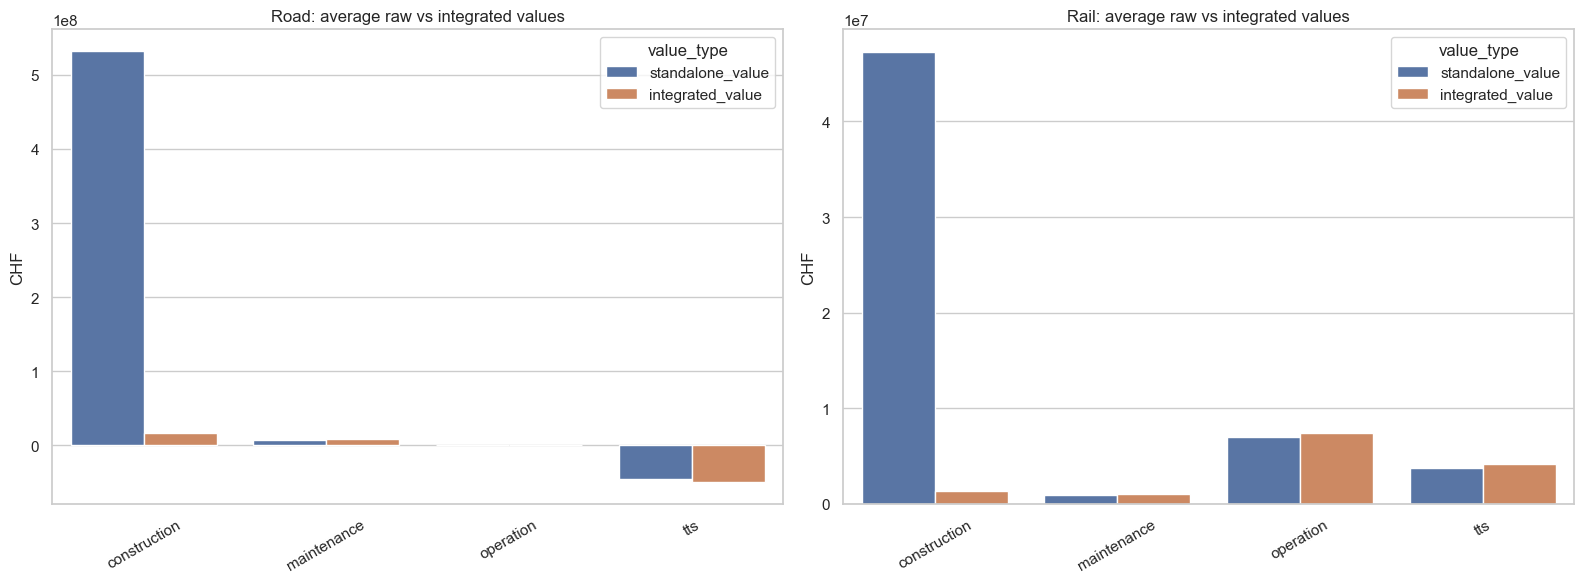

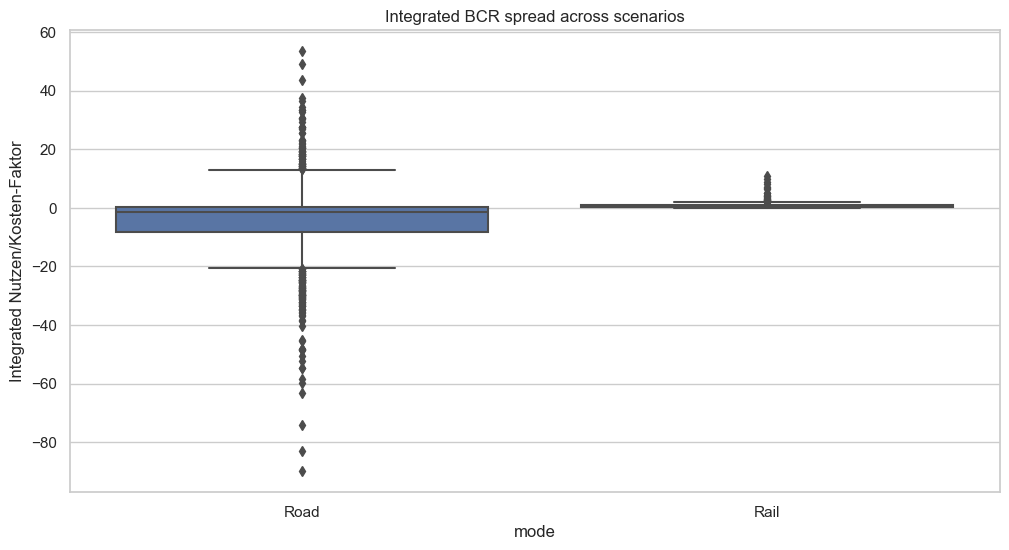

Road TTS minutes source: /Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/traffic_flow/od_trust_xi_all10sce/od_tt_savings_detailed.csv


,mode,development,scenario_count,median_tts_minutes,mean_tts_minutes,std_tts_minutes,min_tts_minutes,max_tts_minutes,q1_tts_minutes,q3_tts_minutes,median_bcr_integrated,iqr_tts_minutes,abs_median_tts_minutes,relative_iqr_tts,relative_std_tts
1,Rail,100001,10,"1,722.24","1,822.57",550.70,"1,048.98","2,750.89","1,388.52","2,160.98",6.86,772.46,"1,722.24",0.45,0.32
7,Rail,101001,10,"1,587.28","1,677.87",500.10,976.71,"2,518.39","1,281.41","1,981.64",0.77,700.23,"1,587.28",0.44,0.32
29,Rail,101023,10,"1,414.14","1,495.06",446.50,868.89,"2,245.75","1,141.38","1,766.77",0.45,625.39,"1,414.14",0.44,0.32
13,Rail,101007,10,"1,332.74","1,410.06",422.93,816.05,"2,122.72","1,076.00","1,667.78",1.27,591.78,"1,332.74",0.44,0.32
18,Rail,101012,10,"1,322.35","1,398.29",418.05,811.79,"2,101.58","1,067.39","1,652.76",1.29,585.38,"1,322.35",0.44,0.32
33,Rail,101027,10,"1,211.29","1,254.68",337.54,806.46,"1,780.63",966.27,"1,454.58",0.71,488.30,"1,211.29",0.40,0.28
17,Rail,101011,10,"1,181.07","1,222.89",328.26,787.59,"1,733.43",941.99,"1,417.10",0.91,475.11,"1,181.07",0.40,0.28
37,Rail,101031,10,"1,005.21","1,063.53",319.02,615.47,"1,601.07",811.54,"1,257.94",0.55,446.40,"1,005.21",0.44,0.32
22,Rail,101016,10,974.26,"1,030.51",309.68,595.86,"1,551.87",785.84,"1,219.98",1.85,434.14,974.26,0.45,0.32
32,Rail,101026,10,815.57,862.84,258.65,499.60,"1,298.61",658.48,"1,020.37",0.41,361.89,815.57,0.44,0.32


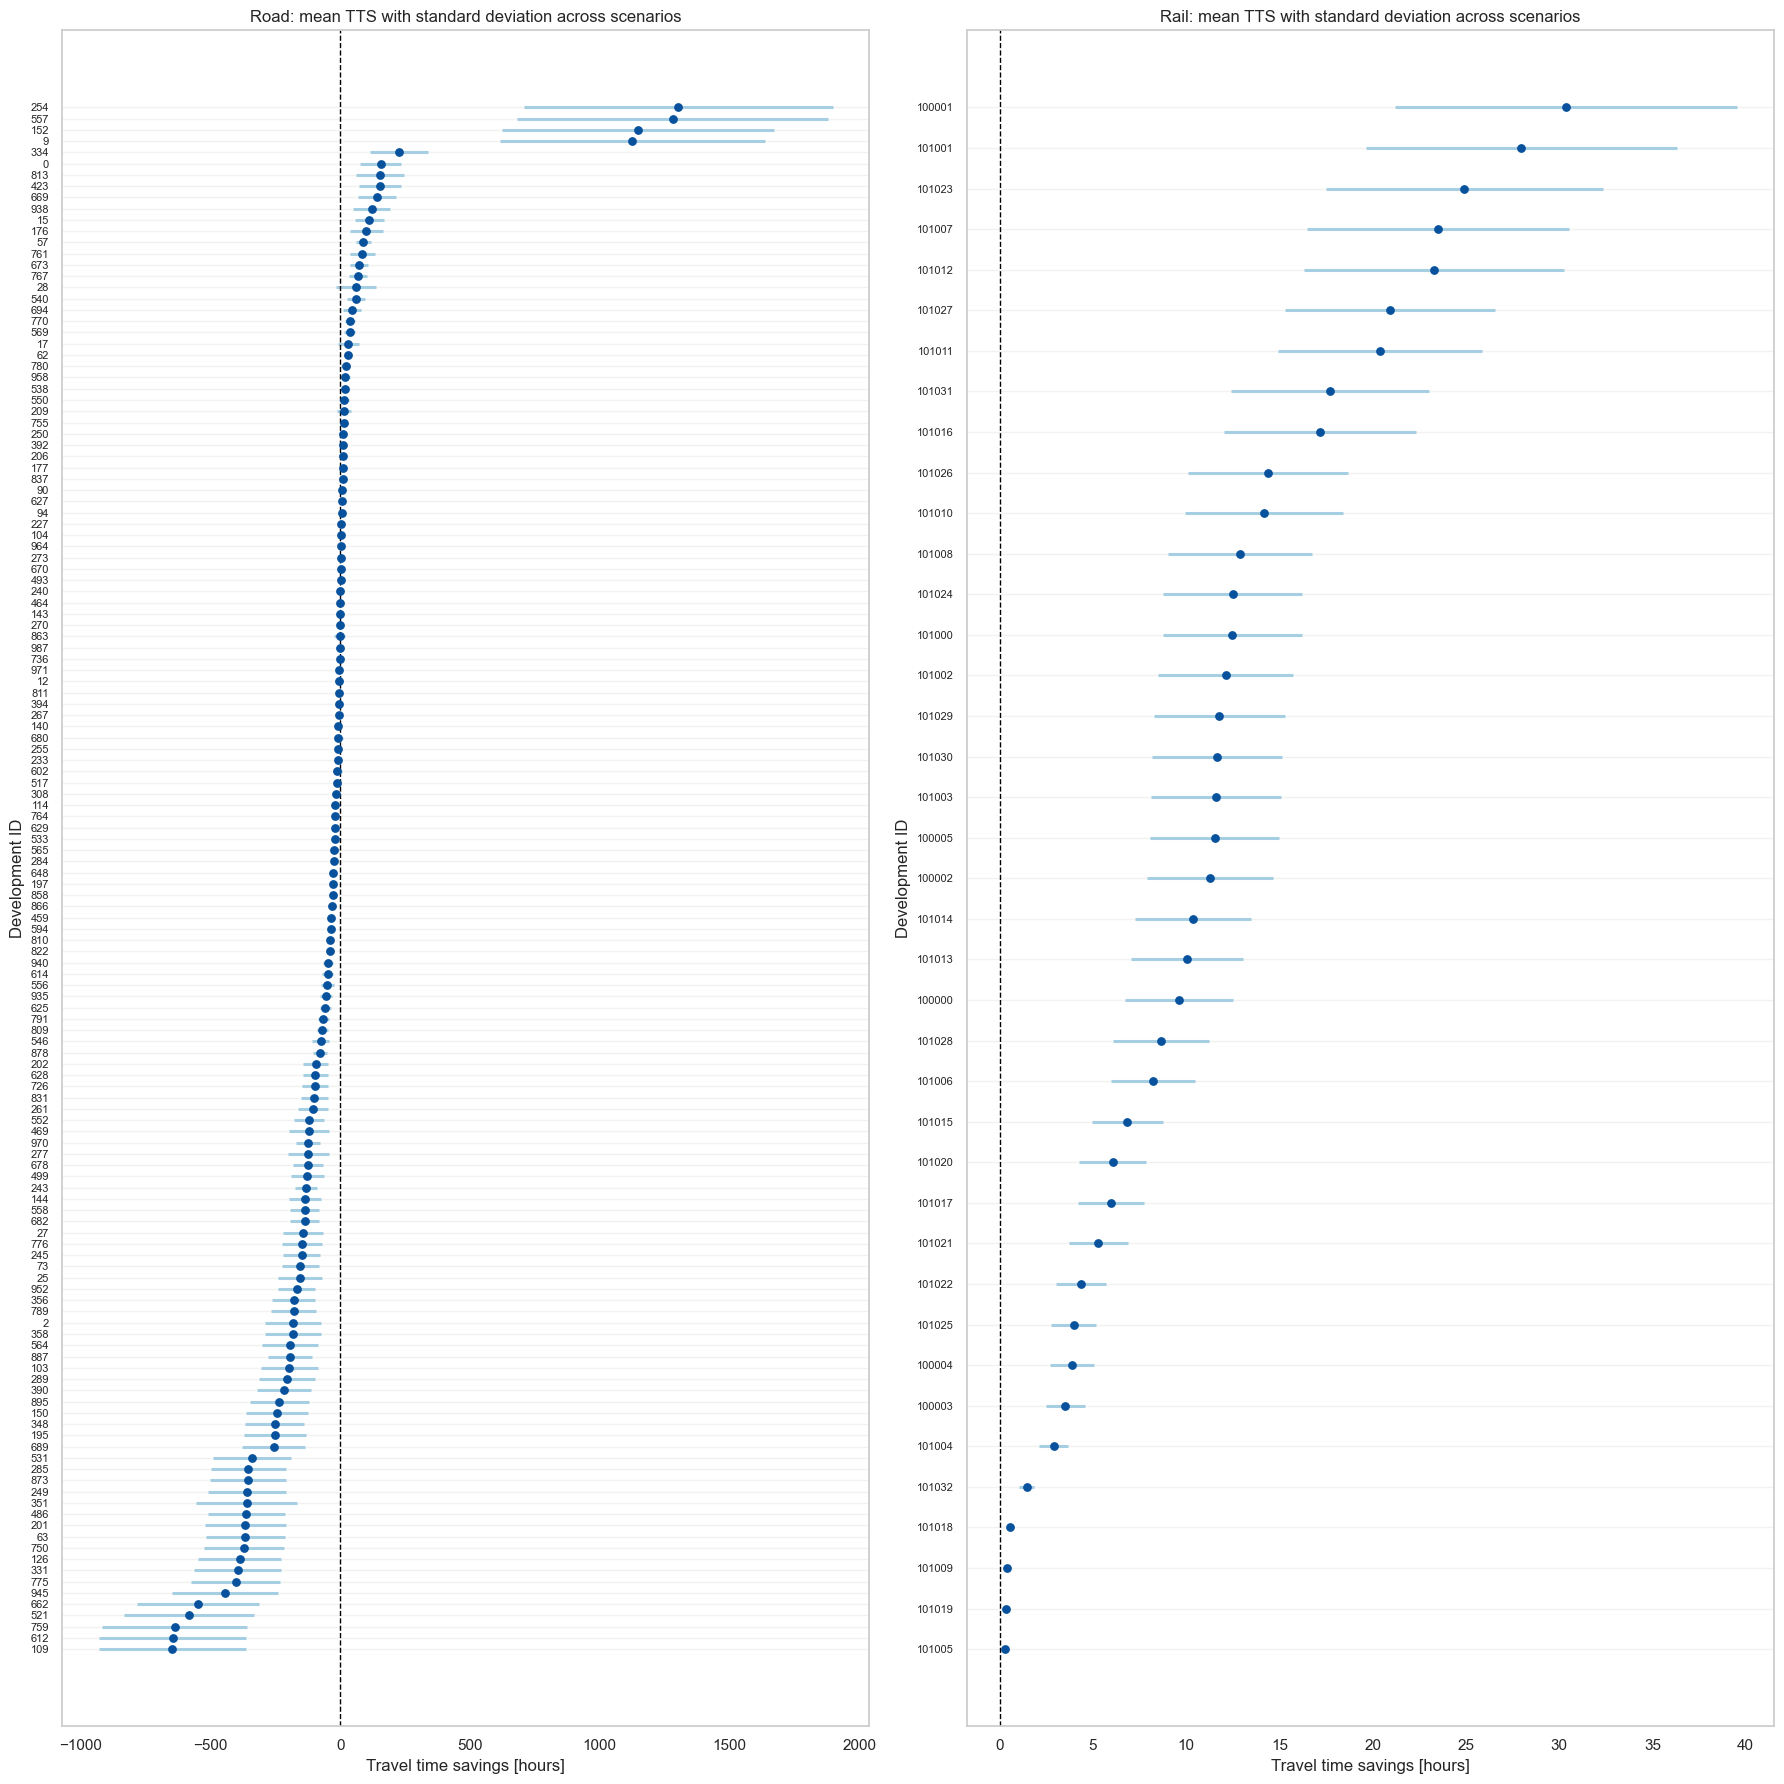

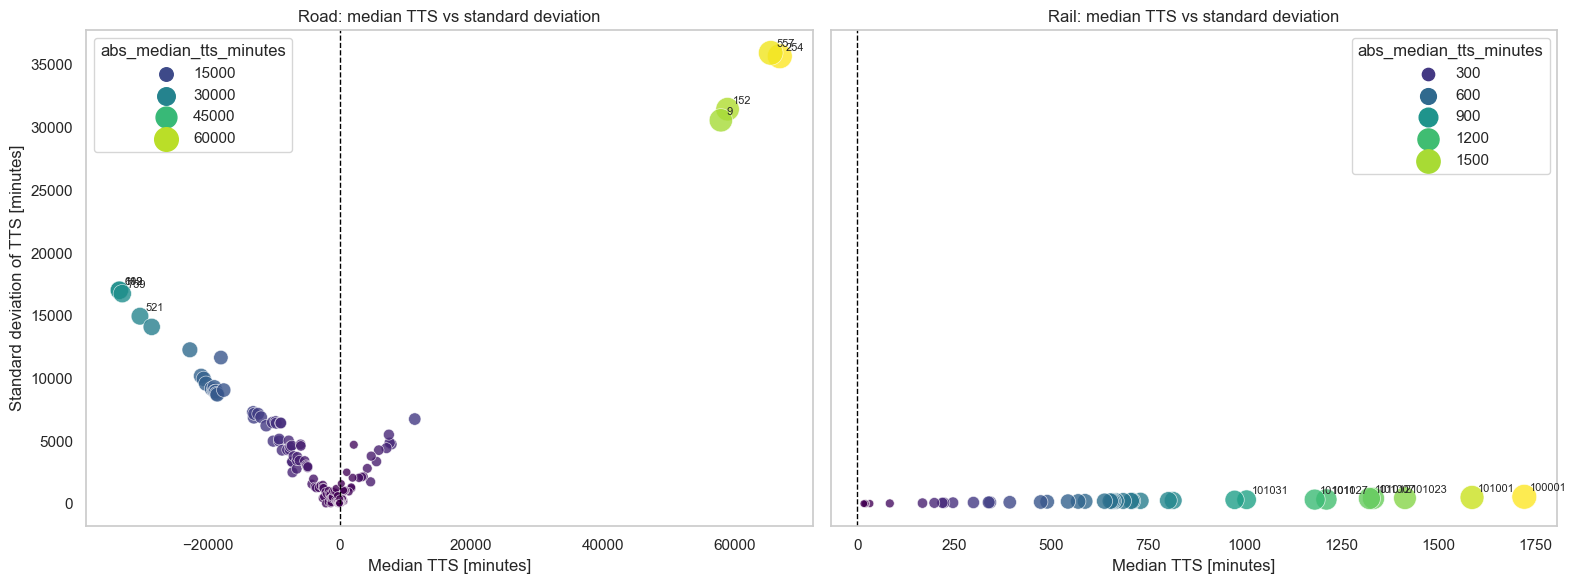

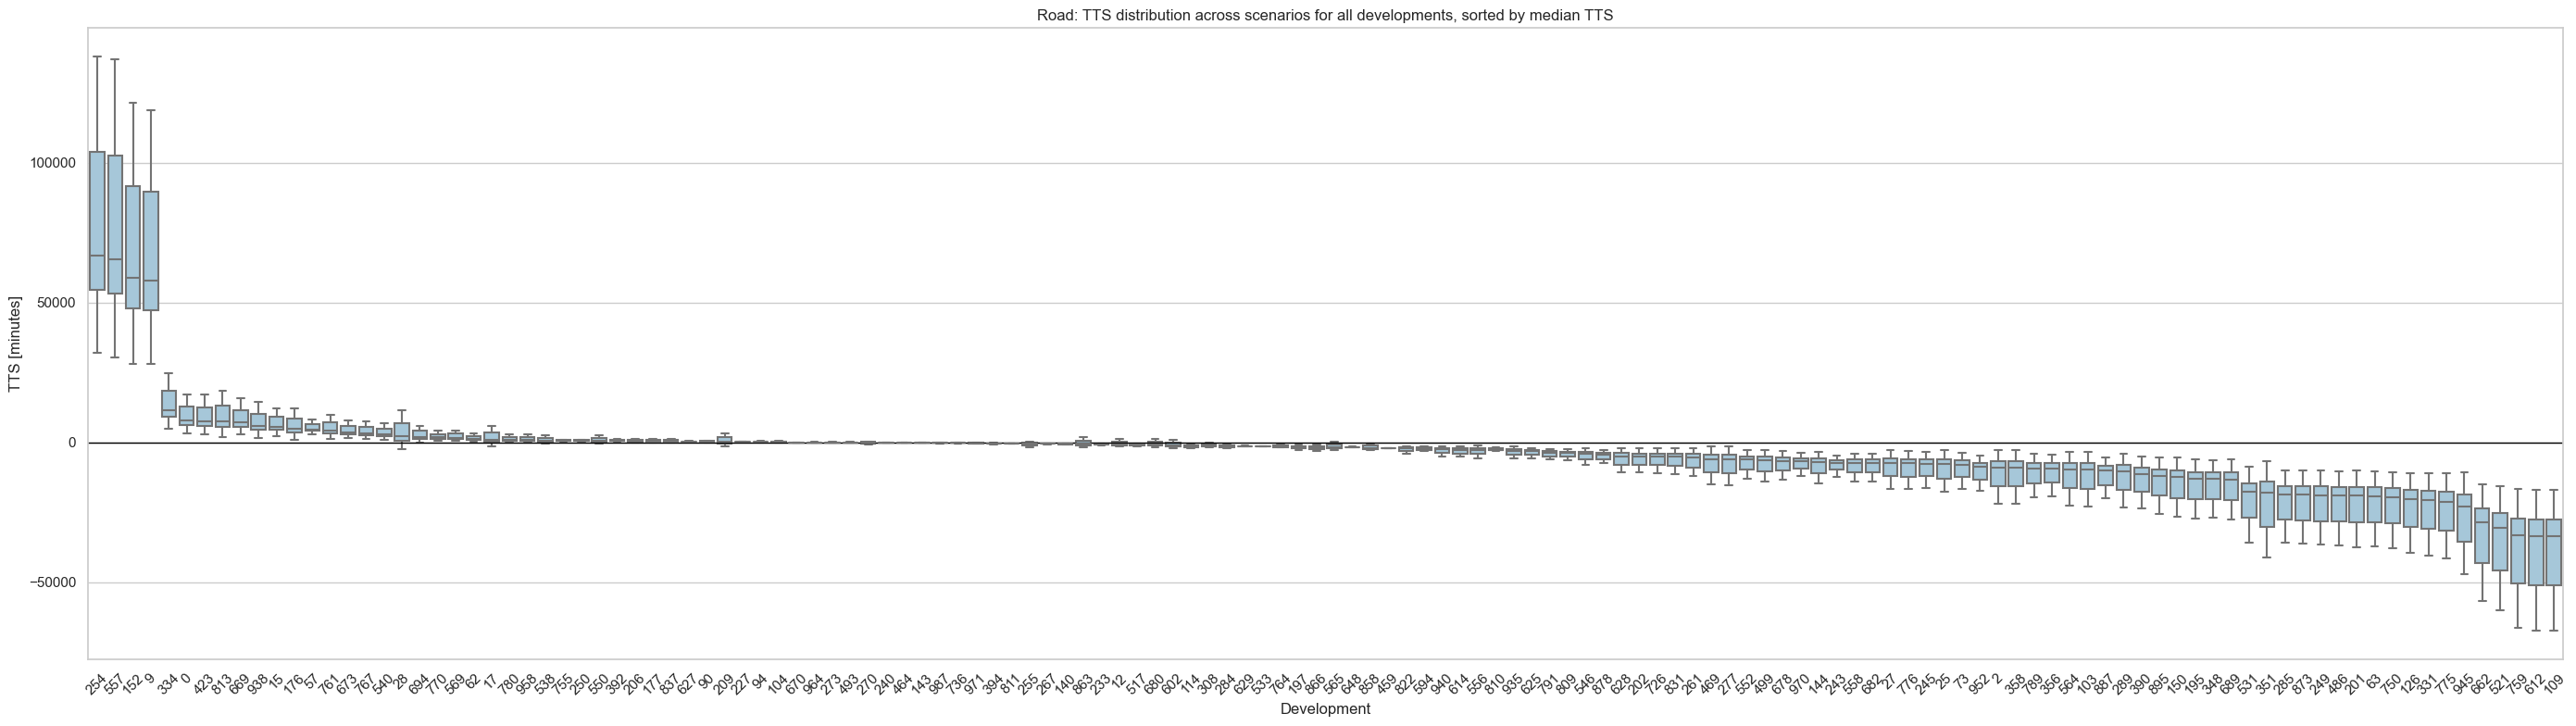

In [16]:
plot_df = score_summary.melt(
    id_vars=["mode", "score_id"],
    value_vars=["standalone_value", "integrated_value"],
    var_name="value_type",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for ax, mode in zip(axes, ["Road", "Rail"]):
    subset = plot_df[(plot_df["mode"] == mode) & (plot_df["score_id"] != "externalities")].copy()
    sns.barplot(data=subset, x="score_id", y="value", hue="value_type", ax=ax)
    ax.set_title(f"{mode}: average raw vs integrated values")
    ax.set_xlabel("")
    ax.set_ylabel("CHF")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()

plt.figure(figsize=(12, 6))
sns.boxplot(data=combined, x="mode", y="bcr_integrated")
plt.title("Integrated BCR spread across scenarios")
plt.ylabel("Integrated Nutzen/Kosten-Faktor")
plt.show()

ROAD_TTS_MINUTES_CANDIDATES = [
    Path("/Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/traffic_flow/od_trust_xi_all10sce/od_tt_savings_detailed.csv"),
    workspace_root / "euler" / "data" / "infraScanRoad" / "traffic_flow" / "od" / "od_trust_xi_all10sce" / "od_tt_savings_detailed.csv",
]


def build_tts_minutes_frame(df: pd.DataFrame) -> pd.DataFrame:
    frames = []

    rail_minutes = df[df["mode"] == "Rail"].copy()
    rail_minutes = rail_minutes[rail_minutes["tt_savings_daily"].notna()].copy()
    rail_minutes = rail_minutes[["mode", "development", "scenario", "tt_savings_daily", "tts_raw", "bcr_integrated"]]
    rail_minutes = rail_minutes.rename(columns={"tt_savings_daily": "tts_minutes", "tts_raw": "tts_chf"})
    # Rail tt_savings_daily is stored as aggregated person-hours.
    # Road tt_savings_peak is stored as aggregated person-minutes.
    # Convert Rail to person-minutes so both modes use the same unit.
    rail_minutes["tts_minutes"] = pd.to_numeric(rail_minutes["tts_minutes"], errors="coerce") * 60.0
    frames.append(rail_minutes)

    road_tts_detailed = None
    road_tts_detailed_path = None
    for candidate in ROAD_TTS_MINUTES_CANDIDATES:
        if candidate.exists():
            road_tts_detailed = pd.read_csv(candidate)
            road_tts_detailed_path = candidate
            break

    if road_tts_detailed is not None:
        if "road_notes" in globals() and "road_scenarios" in road_notes:
            road_tts_detailed = road_tts_detailed[road_tts_detailed["scenario"].isin(road_notes["road_scenarios"])].copy()
        road_minutes = road_tts_detailed[["development", "scenario", "tt_savings_peak", "monetized_savings"]].copy()
        road_minutes["mode"] = "Road"
        road_minutes = road_minutes.rename(columns={"tt_savings_peak": "tts_minutes", "monetized_savings": "tts_chf"})
        road_bcr = df[df["mode"] == "Road"][["development", "scenario", "bcr_integrated"]].copy()
        road_minutes["development"] = normalize_development(road_minutes["development"])
        road_minutes = road_minutes.merge(road_bcr, on=["development", "scenario"], how="left")
        frames.append(road_minutes[["mode", "development", "scenario", "tts_minutes", "tts_chf", "bcr_integrated"]])
        print("Road TTS minutes source:", road_tts_detailed_path)
    else:
        warnings.warn("No Road TTS minutes file found for robustness plots.")

    return pd.concat(frames, ignore_index=True)


def build_tts_robustness(tts_minutes_frame: pd.DataFrame) -> pd.DataFrame:
    metrics = (
        tts_minutes_frame.groupby(["mode", "development"], as_index=False)
        .agg(
            scenario_count=("scenario", "nunique"),
            median_tts_minutes=("tts_minutes", "median"),
            mean_tts_minutes=("tts_minutes", "mean"),
            std_tts_minutes=("tts_minutes", "std"),
            min_tts_minutes=("tts_minutes", "min"),
            max_tts_minutes=("tts_minutes", "max"),
            q1_tts_minutes=("tts_minutes", lambda values: values.quantile(0.25)),
            q3_tts_minutes=("tts_minutes", lambda values: values.quantile(0.75)),
            median_bcr_integrated=("bcr_integrated", "median"),
        )
    )
    metrics["iqr_tts_minutes"] = metrics["q3_tts_minutes"] - metrics["q1_tts_minutes"]
    metrics["abs_median_tts_minutes"] = metrics["median_tts_minutes"].abs()
    metrics["relative_iqr_tts"] = metrics["iqr_tts_minutes"] / metrics["abs_median_tts_minutes"].replace(0, np.nan)
    metrics["relative_std_tts"] = metrics["std_tts_minutes"] / metrics["abs_median_tts_minutes"].replace(0, np.nan)
    return metrics.sort_values(["mode", "abs_median_tts_minutes"], ascending=[True, False])


tts_minutes_frame = build_tts_minutes_frame(combined)
tts_robustness = build_tts_robustness(tts_minutes_frame)
display(tts_robustness.groupby("mode", group_keys=False).head(10))

tts_robustness["mean_tts_hours"] = tts_robustness["mean_tts_minutes"] / 60.0
tts_robustness["std_tts_hours"] = tts_robustness["std_tts_minutes"] / 60.0

fig, axes = plt.subplots(1, 2, figsize=(18, 18), sharex=False)
for ax, mode in zip(axes, ["Road", "Rail"]):
    subset = tts_robustness[tts_robustness["mode"] == mode].copy()
    subset = subset.sort_values("mean_tts_hours", ascending=False).reset_index(drop=True)
    y_pos = np.arange(len(subset))
    lower = subset["mean_tts_hours"] - subset["std_tts_hours"].fillna(0)
    upper = subset["mean_tts_hours"] + subset["std_tts_hours"].fillna(0)

    ax.hlines(y=y_pos, xmin=lower, xmax=upper, color="#9ecae1", linewidth=2.2, alpha=0.9)
    ax.scatter(subset["mean_tts_hours"], y_pos, color="#08519c", s=28, zorder=3)
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.grid(False)          # alle Gridlines aus
    ax.xaxis.grid(False)    # sicherheitshalber vertikale Gridlines aus
    ax.set_yticks(y_pos)
    ax.set_yticklabels(subset["development"].astype(str), fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f"{mode}: mean TTS with standard deviation across scenarios")
    ax.set_xlabel("Travel time savings [person-hours]")
    ax.set_ylabel("Development ID")
    ax.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, mode in zip(axes, ["Road", "Rail"]):
    subset = tts_robustness[tts_robustness["mode"] == mode].copy()
    sns.scatterplot(
        data=subset,
        x="median_tts_minutes",
        y="std_tts_minutes",
        size="abs_median_tts_minutes",
        hue="abs_median_tts_minutes",
        palette="viridis",
        sizes=(30, 320),
        alpha=0.8,
        ax=ax,
    )
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"{mode}: median TTS vs standard deviation")
    ax.set_xlabel("Median TTS [person-minutes]")
    ax.set_ylabel("Standard deviation of TTS [person-minutes]")
    ax.grid(False)

    label_subset = subset.sort_values("abs_median_tts_minutes", ascending=False).head(8)
    for _, row in label_subset.iterrows():
        ax.annotate(
            str(row["development"]),
            (row["median_tts_minutes"], row["std_tts_minutes"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

road_tts_order = (
    tts_robustness[tts_robustness["mode"] == "Road"]
    .sort_values("median_tts_minutes", ascending=False)["development"]
    .astype(str)
    .tolist()
)
road_boxplot_df = tts_minutes_frame[
    (tts_minutes_frame["mode"] == "Road")
    & (tts_minutes_frame["development"].astype(str).isin(road_tts_order))
].copy()
road_boxplot_df["development"] = pd.Categorical(road_boxplot_df["development"].astype(str), categories=road_tts_order, ordered=True)

plt.figure(figsize=(28, 8))
sns.boxplot(data=road_boxplot_df, x="development", y="tts_minutes", color="#9ecae1")
plt.axhline(0, color="black", linewidth=1)
plt.title("Road: aggregated TTS distribution across scenarios, sorted by median TTS")
plt.xlabel("Development")
plt.ylabel("TTS [person-minutes]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
std_threshold_hours = 800 / 60.0

high_uncertainty_devs = (
    tts_robustness.loc[tts_robustness["std_tts_hours"] > std_threshold_hours, [
        "mode",
        "development",
        "scenario_count",
        "mean_tts_hours",
        "std_tts_hours",
        "mean_tts_minutes",
        "std_tts_minutes",
    ]]
    .sort_values(["mode", "std_tts_hours"], ascending=[True, False])
    .reset_index(drop=True)
)

display(high_uncertainty_devs)
print(f"Developments with std > {std_threshold_hours} hours: {len(high_uncertainty_devs)}")

,mode,development,scenario_count,mean_tts_hours,std_tts_hours,mean_tts_minutes,std_tts_minutes
0,Road,557,10,"1,280.44",599.46,"76,826.64","35,967.33"
1,Road,254,10,"1,301.96",595.03,"78,117.49","35,702.01"
2,Road,152,10,"1,147.47",524.54,"68,848.38","31,472.32"
3,Road,9,10,"1,125.87",509.81,"67,552.49","30,588.80"
4,Road,612,10,-646.68,283.84,"-38,800.65","17,030.28"
...,...,...,...,...,...,...,...
91,Road,602,10,-11.99,16.60,-719.51,996.20
92,Road,680,10,-7.85,16.22,-471.17,973.06
93,Road,62,10,28.63,15.95,"1,717.94",957.12
94,Road,822,10,-40.45,15.70,"-2,426.98",942.14


Developments with std > 13.333333333333334 hours: 96


In [18]:
std_threshold_hours = 800 / 60.0

selected_developments = (
    tts_robustness.loc[tts_robustness["std_tts_hours"] <= std_threshold_hours, [
        "mode",
        "development",
        "mean_tts_hours",
        "std_tts_hours",
    ]]
    .copy()
)

display(selected_developments.sort_values(["mode", "mean_tts_hours"], ascending=[True, False]))
print(f"Selected developments: {len(selected_developments)}")

,mode,development,mean_tts_hours,std_tts_hours
1,Rail,100001,30.38,9.18
7,Rail,101001,27.96,8.34
29,Rail,101023,24.92,7.44
13,Rail,101007,23.50,7.05
18,Rail,101012,23.30,6.97
...,...,...,...,...
157,Road,858,-28.19,12.91
159,Road,866,-30.20,12.76
93,Road,459,-34.50,0.26
115,Road,594,-36.33,9.30


Selected developments: 81


,mode,scenario,mean_nb_integrated,median_nb_integrated,std_nb_integrated,positive_share
1,Rail,scenario_19,"-6,168,092.91","-6,068,806.05","6,285,714.16",0.18
2,Rail,scenario_26,"-7,390,462.36","-7,490,457.95","5,902,696.42",0.08
3,Rail,scenario_44,"-5,115,516.39","-4,911,039.38","6,691,029.77",0.23
4,Rail,scenario_64,"-4,882,041.04","-4,643,691.01","6,790,983.44",0.23
5,Rail,scenario_70,"-6,871,742.35","-6,891,212.97","6,052,109.90",0.10
6,Rail,scenario_75,"-5,813,815.45","-5,699,761.81","6,416,565.82",0.18
7,Rail,scenario_78,"-3,642,595.72","-3,226,938.40","7,349,692.68",0.33
8,Rail,scenario_89,"-5,984,146.81","-5,906,305.84","6,354,286.51",0.18
9,Rail,scenario_96,"-4,147,957.00","-3,842,973.15","7,113,773.67",0.33
0,Rail,scenario_100,"-6,825,107.49","-6,837,138.50","6,067,508.86",0.10


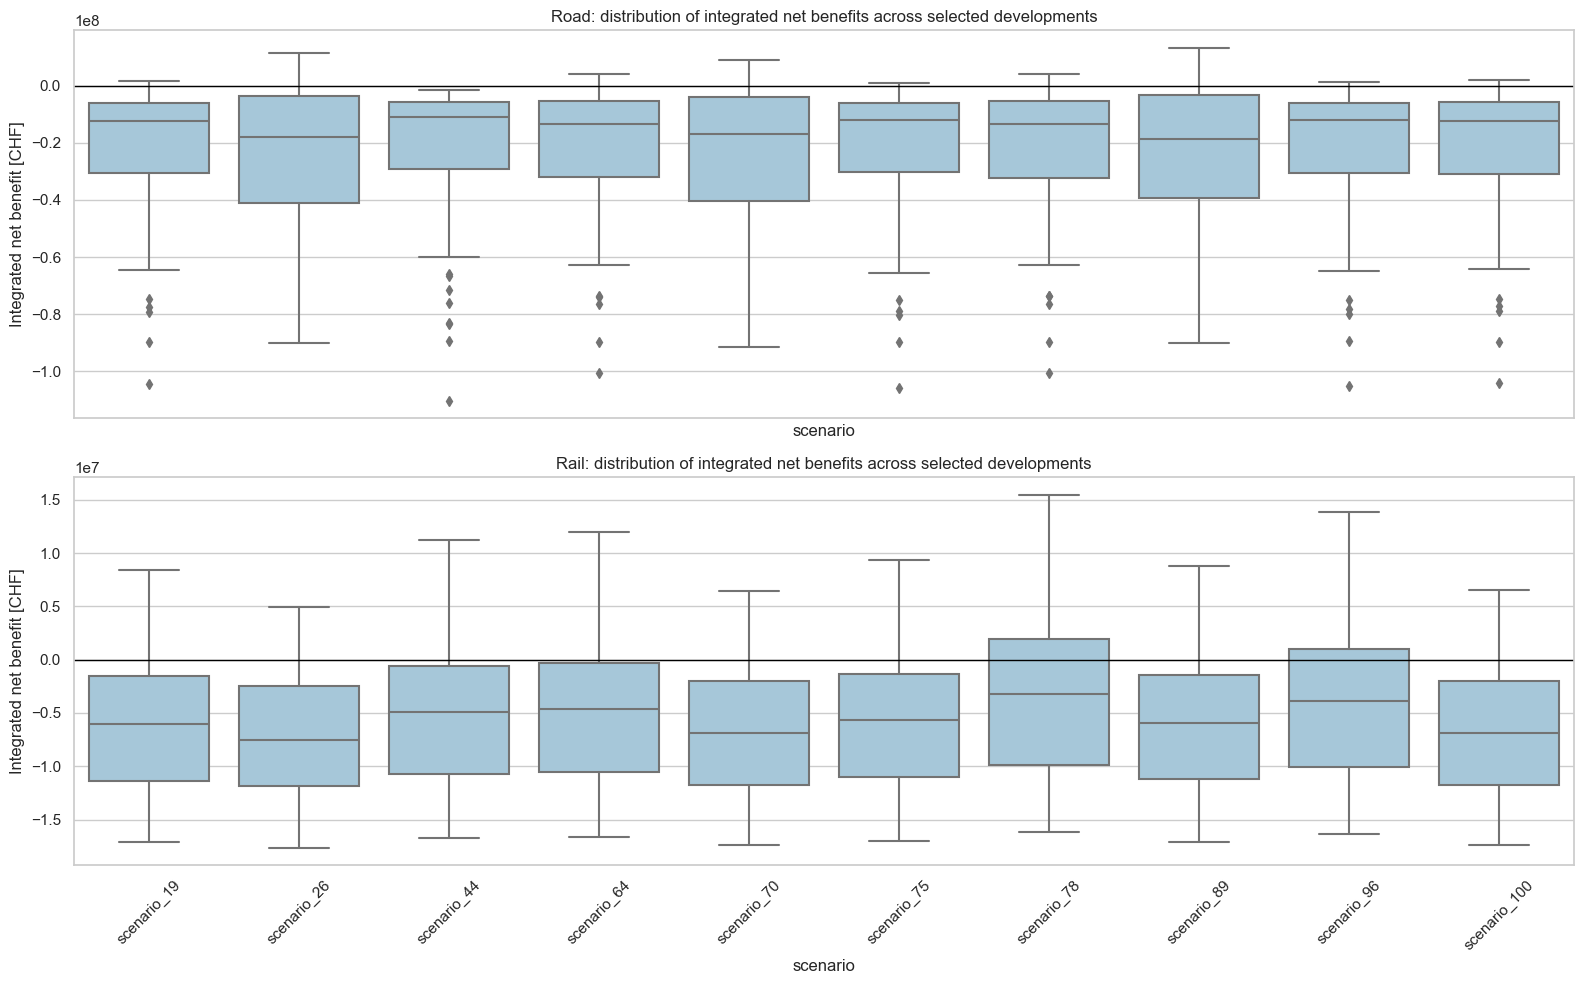

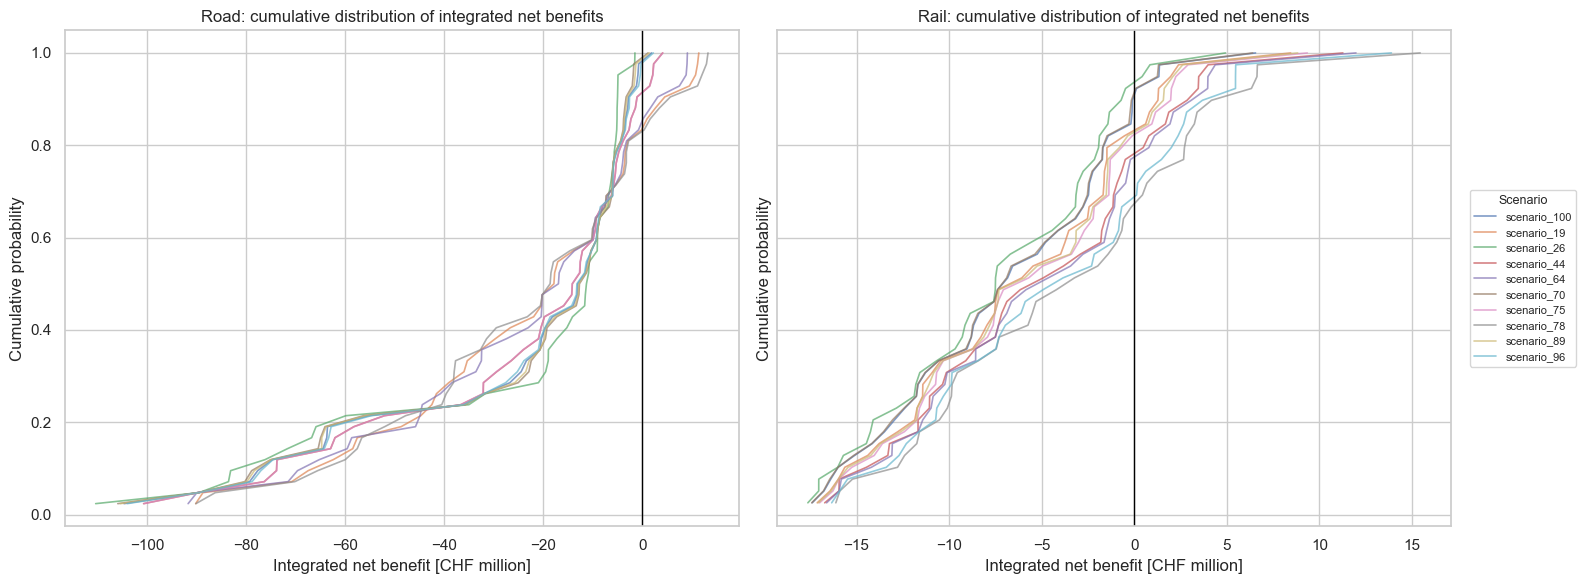

In [19]:
analysis_df = combined.merge(
    selected_developments[["mode", "development"]],
    on=["mode", "development"],
    how="inner",
)


net_benefit_distribution_summary = (
    analysis_df.groupby(["mode", "scenario"], as_index=False)
    .agg(
        mean_nb_integrated=("net_benefit_integrated", "mean"),
        median_nb_integrated=("net_benefit_integrated", "median"),
        std_nb_integrated=("net_benefit_integrated", "std"),
        positive_share=("net_benefit_integrated", lambda values: float((values > 0).mean())),
    )
)

display(
    net_benefit_distribution_summary.sort_values(
        ["mode", "scenario"],
        key=lambda col: col.map(scenario_number) if col.name == "scenario" else col,
    )
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
for ax, mode in zip(axes, ["Road", "Rail"]):
    subset = analysis_df[analysis_df["mode"] == mode].copy()
    sns.boxplot(data=subset, x="scenario", y="net_benefit_integrated", ax=ax, color="#9ecae1")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{mode}: distribution of integrated net benefits across selected developments")
    ax.set_ylabel("Integrated net benefit [CHF]")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, mode in zip(axes, ["Road", "Rail"]):
    subset = analysis_df[analysis_df["mode"] == mode].copy()
    for scenario, scenario_df in subset.groupby("scenario"):
        values = np.sort(scenario_df["net_benefit_integrated"].dropna().values / 1_000_000)
        if len(values) == 0:
            continue
        y_values = np.arange(1, len(values) + 1) / len(values)
        ax.plot(values, y_values, linewidth=1.2, alpha=0.7, label=scenario)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{mode}: cumulative distribution of integrated net benefits")
    ax.set_xlabel("Integrated net benefit [CHF million]")
    ax.set_ylabel("Cumulative probability")
axes[1].legend(title="Scenario", fontsize=8, title_fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

In [ ]:
# Net benefit robustness: one line per development across scenarios
# Uses the same filtered development set as the cumulative distribution plot (`analysis_df`).
# To plot all developments instead, replace `analysis_df` with `combined` below.

plot_base = analysis_df.copy()
plot_base["net_benefit_mio"] = plot_base["net_benefit_integrated"] / 1_000_000
plot_base["scenario_order"] = plot_base["scenario"].map(scenario_number)

# Keep the plot readable: show the strongest developments per mode by median net benefit.
# Set to None to show every selected development.
top_n_developments_per_mode = 12

if top_n_developments_per_mode is None:
    line_plot_df = plot_base.copy()
else:
    top_developments = (
        plot_base.groupby(["mode", "development"], as_index=False)
        .agg(median_net_benefit_mio=("net_benefit_mio", "median"))
        .sort_values(["mode", "median_net_benefit_mio"], ascending=[True, False])
        .groupby("mode", group_keys=False)
        .head(top_n_developments_per_mode)
    )
    line_plot_df = plot_base.merge(top_developments[["mode", "development"]], on=["mode", "development"], how="inner")

line_plot_df = line_plot_df.sort_values(["mode", "development", "scenario_order"])

display(
    line_plot_df.groupby(["mode", "development"], as_index=False)
    .agg(
        scenario_count=("scenario", "nunique"),
        median_net_benefit_mio=("net_benefit_mio", "median"),
        mean_net_benefit_mio=("net_benefit_mio", "mean"),
        std_net_benefit_mio=("net_benefit_mio", "std"),
        min_net_benefit_mio=("net_benefit_mio", "min"),
        max_net_benefit_mio=("net_benefit_mio", "max"),
    )
    .sort_values(["mode", "median_net_benefit_mio"], ascending=[True, False])
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
for ax, mode in zip(axes, ["Road", "Rail"]):
    subset = line_plot_df[line_plot_df["mode"] == mode].copy()
    if subset.empty:
        ax.set_title(f"{mode}: no data")
        ax.axis("off")
        continue

    sns.lineplot(
        data=subset,
        x="scenario",
        y="net_benefit_mio",
        hue="development",
        marker="o",
        linewidth=1.5,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"{mode}: integrated net benefit across scenarios")
    ax.set_xlabel("Scenario")
    ax.set_ylabel("Integrated net benefit [CHF million]")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.25)
    ax.grid(False, axis="x")
    ax.legend(title="Development", fontsize=8, title_fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plot_path = OUTPUT_DIR / "integrated_net_benefit_lines_by_development.png"
plt.savefig(plot_path, dpi=240, bbox_inches="tight")
print(f"Saved plot to: {plot_path}")
plt.show()


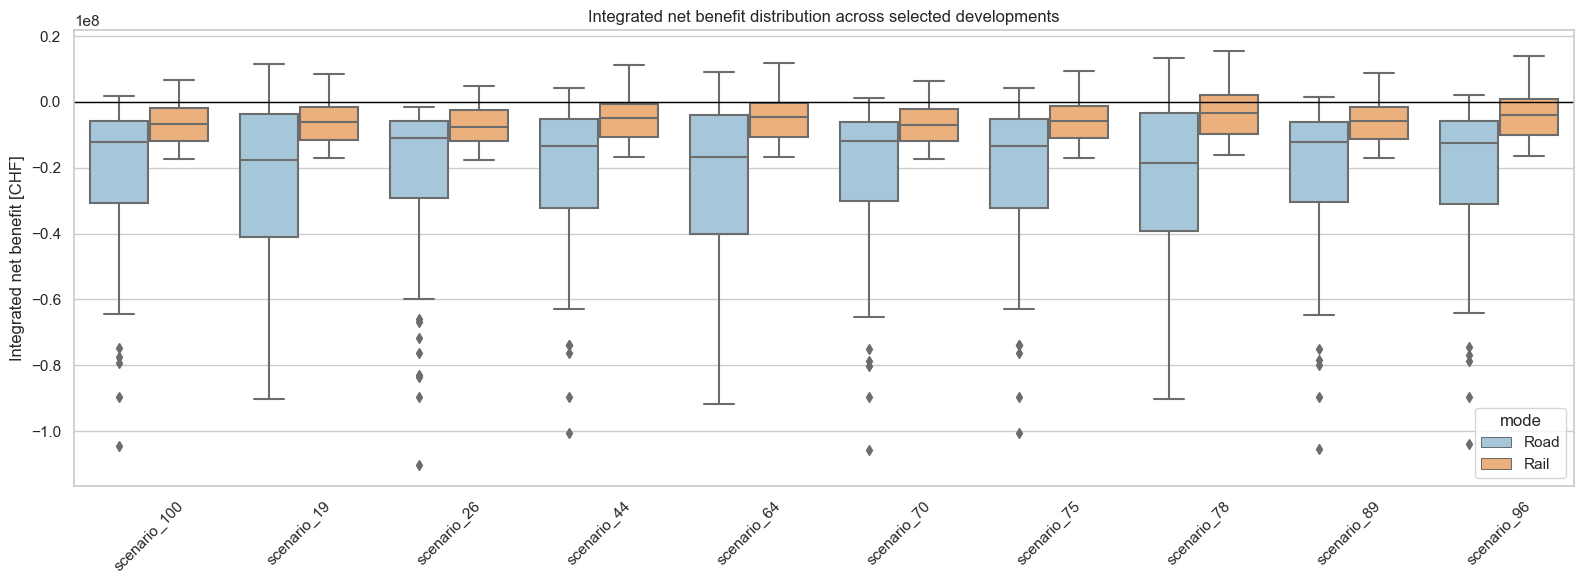

In [20]:
analysis_df = analysis_df.copy()

plt.figure(figsize=(16, 6))
sns.boxplot(
    data=analysis_df,
    x="scenario",
    y="net_benefit_integrated",
    hue="mode",
    palette={"Road": "#9ecae1", "Rail": "#fdae6b"},
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Integrated net benefit distribution across selected developments")
plt.ylabel("Integrated net benefit [CHF]")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

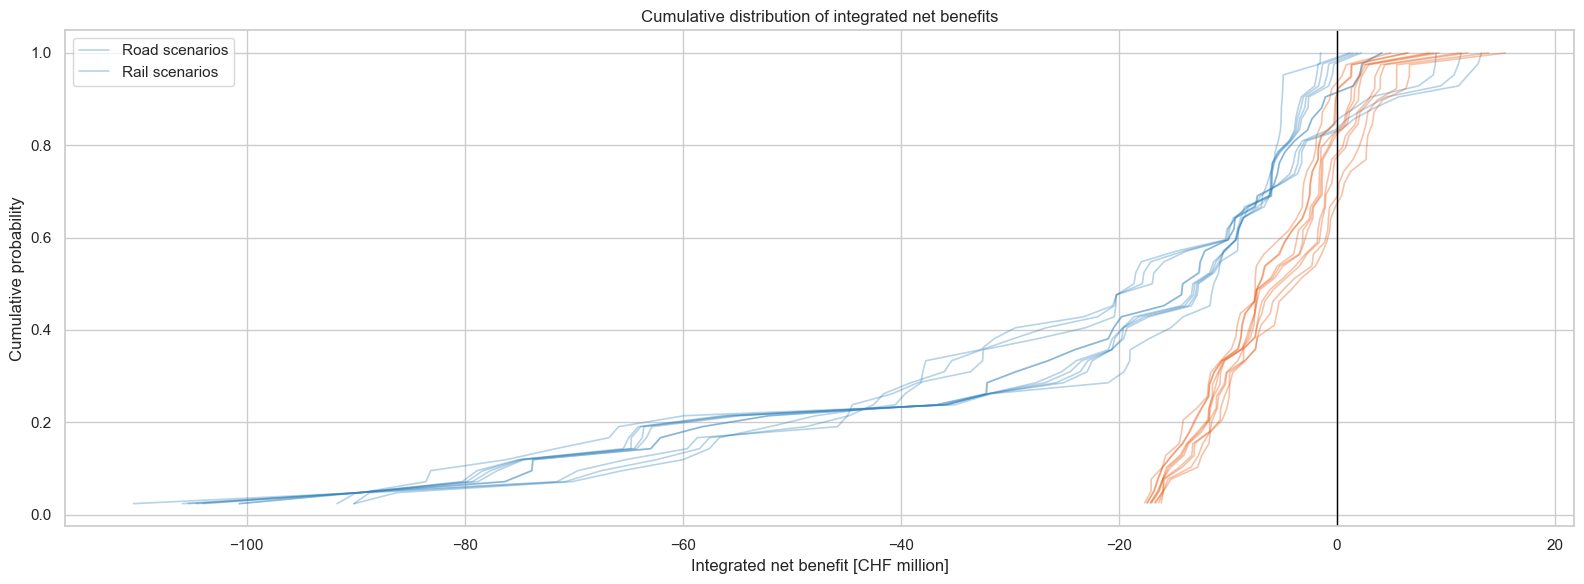

In [21]:
plt.figure(figsize=(16, 6))

for mode, color in [("Road", "#3182bd"), ("Rail", "#e6550d")]:
    subset = analysis_df[analysis_df["mode"] == mode].copy()
    for scenario, scenario_df in subset.groupby("scenario"):
        values = np.sort(scenario_df["net_benefit_integrated"].dropna().values / 1_000_000)
        if len(values) == 0:
            continue
        y_values = np.arange(1, len(values) + 1) / len(values)
        plt.plot(
            values,
            y_values,
            linewidth=1.2,
            alpha=0.35,
            color=color,
        )

plt.axvline(0, color="black", linewidth=1)
plt.title("Cumulative distribution of integrated net benefits")
plt.xlabel("Integrated net benefit [CHF million]")
plt.ylabel("Cumulative probability")
plt.legend(["Road scenarios", "Rail scenarios"])
plt.tight_layout()
plt.show()

In [22]:

ROAD_TTS_MINUTES_CANDIDATES = [
    Path("/Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/traffic_flow/od_trust_xi_all10sce/od_tt_savings_detailed.csv"),
    workspace_root / "euler" / "data" / "infraScanRoad" / "traffic_flow" / "od" / "od_trust_xi_all10sce" / "od_tt_savings_detailed.csv",
]

road_tts_detailed = None
road_tts_detailed_path = None

for candidate in ROAD_TTS_MINUTES_CANDIDATES:
    if candidate.exists():
        road_tts_detailed = pd.read_csv(candidate)
        road_tts_detailed_path = candidate
        break

if road_tts_detailed is None:
    warnings.warn("No detailed Road TTS decomposition file found.")
else:
    if "road_notes" in globals() and "road_scenarios" in road_notes:
        road_tts_detailed = road_tts_detailed[
            road_tts_detailed["scenario"].isin(road_notes["road_scenarios"])
        ].copy()

    print("Detailed Road TTS file:", road_tts_detailed_path)
    display(road_tts_detailed.head())
    print(road_tts_detailed.shape)

Detailed Road TTS file: /Volumes/WD_Windows/MSc_Thesis/euler/data/infraScanRoad/traffic_flow/od_trust_xi_all10sce/od_tt_savings_detailed.csv


,development,scenario,status_quo_origin_access_tt,status_quo_network_tt,status_quo_destination_access_tt,status_quo_total_tt,development_origin_access_tt,development_network_tt,development_destination_access_tt,development_total_tt,origin_access_savings,network_savings,destination_access_savings,tt_savings_peak,monetized_savings_yearly,monetized_savings
0,0,scenario_100,"28,665.44","532,633.69","28,665.44","589,964.56","28,433.70","526,528.84","28,433.70","583,396.25",231.73,"6,104.84",231.73,"6,568.30","2,148,382.84","85,935,313.51"
1,2,scenario_100,"28,665.44","532,633.69","28,665.44","589,964.56","26,722.98","543,654.67","26,722.98","597,100.62","1,942.46","-11,020.98","1,942.46","-7,136.06","-2,334,087.27","-93,363,490.88"
2,9,scenario_100,"28,665.44","532,633.69","28,665.44","589,964.56","26,393.00","487,737.62","26,393.00","540,523.62","2,272.43","44,896.07","2,272.43","49,440.93","16,171,305.21","646,852,208.27"
3,12,scenario_100,"28,665.44","532,633.69","28,665.44","589,964.56","28,589.95","533,601.01","28,589.95","590,780.92",75.48,-967.33,75.48,-816.36,"-267,018.72","-10,680,748.94"
4,15,scenario_100,"28,665.44","532,633.69","28,665.44","589,964.56","28,518.48","528,253.51","28,518.48","585,290.46",146.96,"4,380.18",146.96,"4,674.09","1,528,818.19","61,152,727.66"


(1380, 16)


,development,scenario,tts_raw,tts_integrated,bcr_integrated,net_benefit_integrated,construction_raw,maintenance_raw,externalities_raw
178,254,scenario_19,"1,663,507,581.41","1,852,889,639.18",30.30,"1,791,732,954.15","1,323,823,495.56","16,878,219.35","395,701,901.59"
316,254,scenario_26,"418,817,268.48","466,497,529.77",7.63,"405,340,844.73","1,323,823,495.56","16,878,219.35","395,701,901.59"
454,254,scenario_44,"970,159,168.74","1,080,606,960.98",17.67,"1,019,450,275.95","1,323,823,495.56","16,878,219.35","395,701,901.59"
592,254,scenario_64,"1,486,191,139.14","1,655,386,602.59",27.07,"1,594,229,917.55","1,323,823,495.56","16,878,219.35","395,701,901.59"
730,254,scenario_70,"674,137,935.14","750,885,183.43",12.28,"689,728,498.40","1,323,823,495.56","16,878,219.35","395,701,901.59"
868,254,scenario_75,"973,942,461.07","1,084,820,962.32",17.74,"1,023,664,277.28","1,323,823,495.56","16,878,219.35","395,701,901.59"
1006,254,scenario_78,"1,803,573,337.87","2,008,901,184.82",32.85,"1,947,744,499.79","1,323,823,495.56","16,878,219.35","395,701,901.59"
1144,254,scenario_89,"703,496,551.11","783,586,131.70",12.81,"722,429,446.66","1,323,823,495.56","16,878,219.35","395,701,901.59"
1282,254,scenario_96,"781,046,220.18","869,964,444.57",14.23,"808,807,759.54","1,323,823,495.56","16,878,219.35","395,701,901.59"
40,254,scenario_100,"745,499,534.31","830,370,945.45",13.58,"769,214,260.42","1,323,823,495.56","16,878,219.35","395,701,901.59"


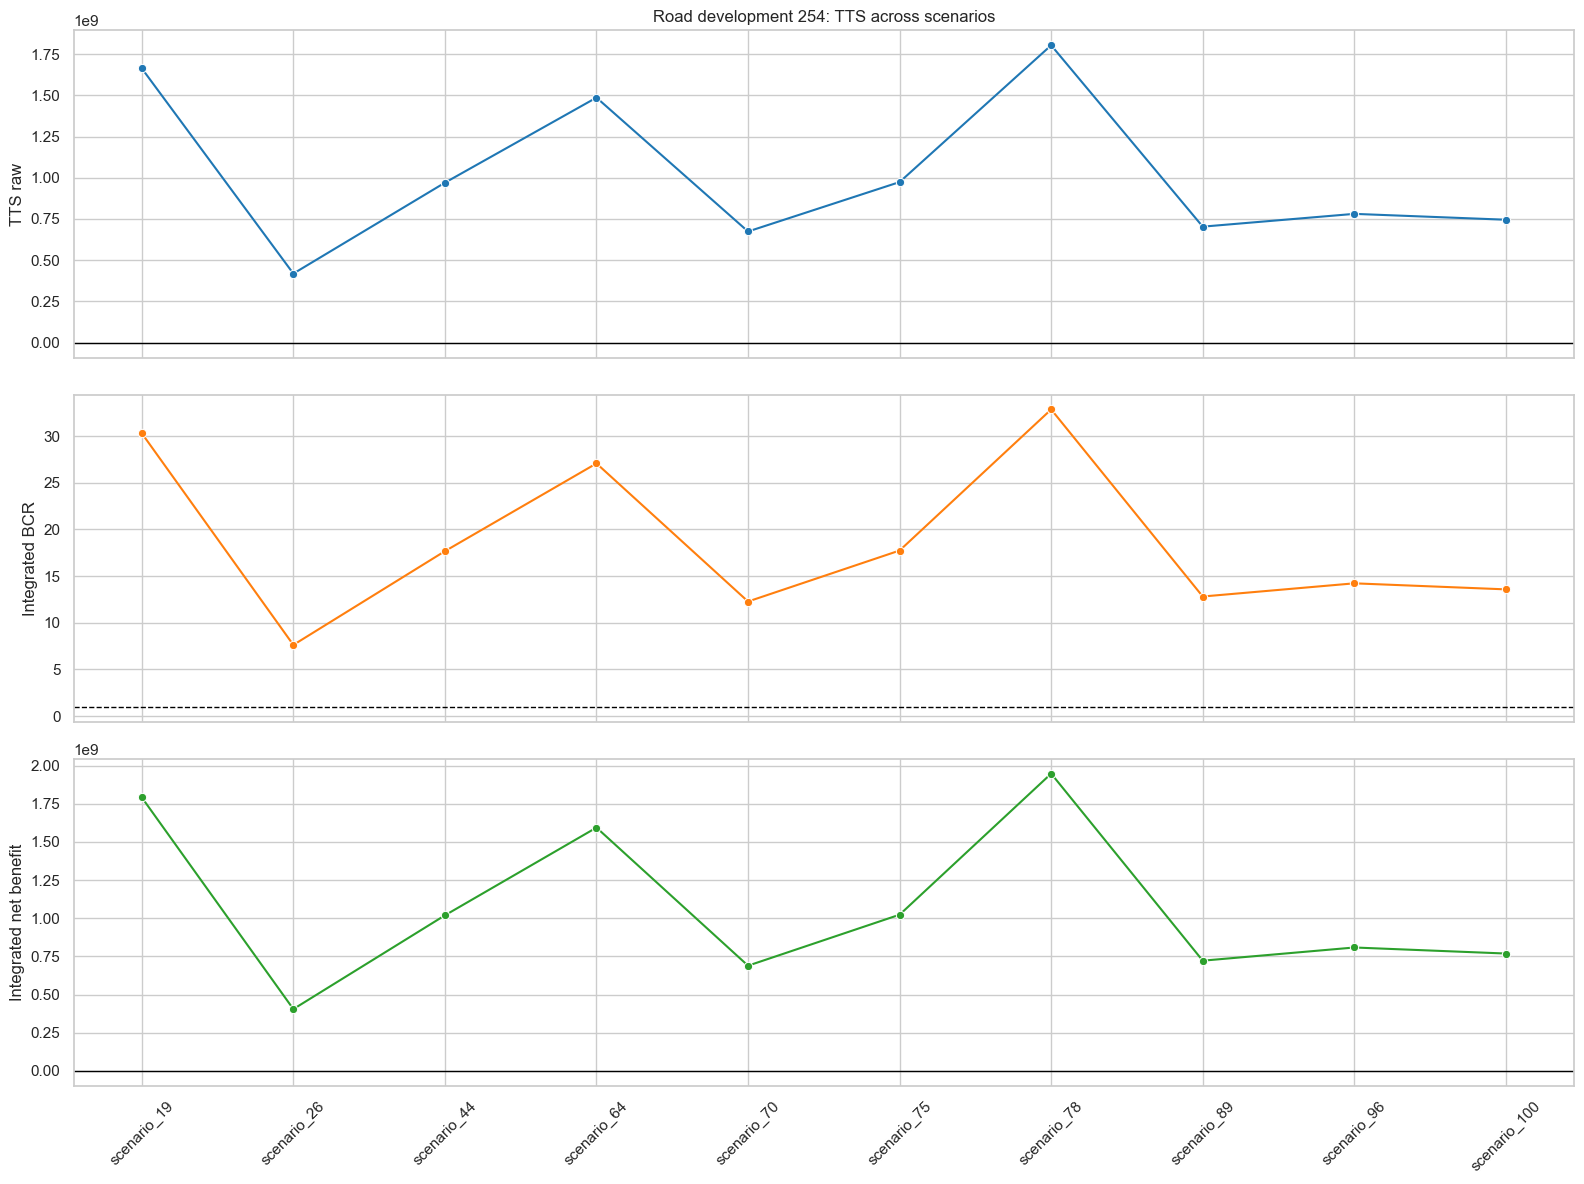

,development,scenario,origin_access_savings,network_savings,destination_access_savings,tt_savings_peak,monetized_savings
178,254,scenario_19,"2,552.96","122,041.15","2,552.96","127,147.08","1,663,507,581.41"
316,254,scenario_26,"2,552.96","26,905.58","2,552.96","32,011.51","418,817,268.48"
454,254,scenario_44,"2,552.96","69,046.36","2,552.96","74,152.29","970,159,168.74"
592,254,scenario_64,"2,552.96","108,488.30","2,552.96","113,594.23","1,486,191,139.14"
730,254,scenario_70,"2,552.96","46,420.54","2,552.96","51,526.47","674,137,935.14"
868,254,scenario_75,"2,552.96","69,335.53","2,552.96","74,441.46","973,942,461.07"
1006,254,scenario_78,"2,552.96","132,746.81","2,552.96","137,852.74","1,803,573,337.87"
1144,254,scenario_89,"2,552.96","48,664.51","2,552.96","53,770.44","703,496,551.11"
1282,254,scenario_96,"2,552.96","54,591.87","2,552.96","59,697.80","781,046,220.18"
40,254,scenario_100,"2,552.96","51,874.93","2,552.96","56,980.86","745,499,534.31"


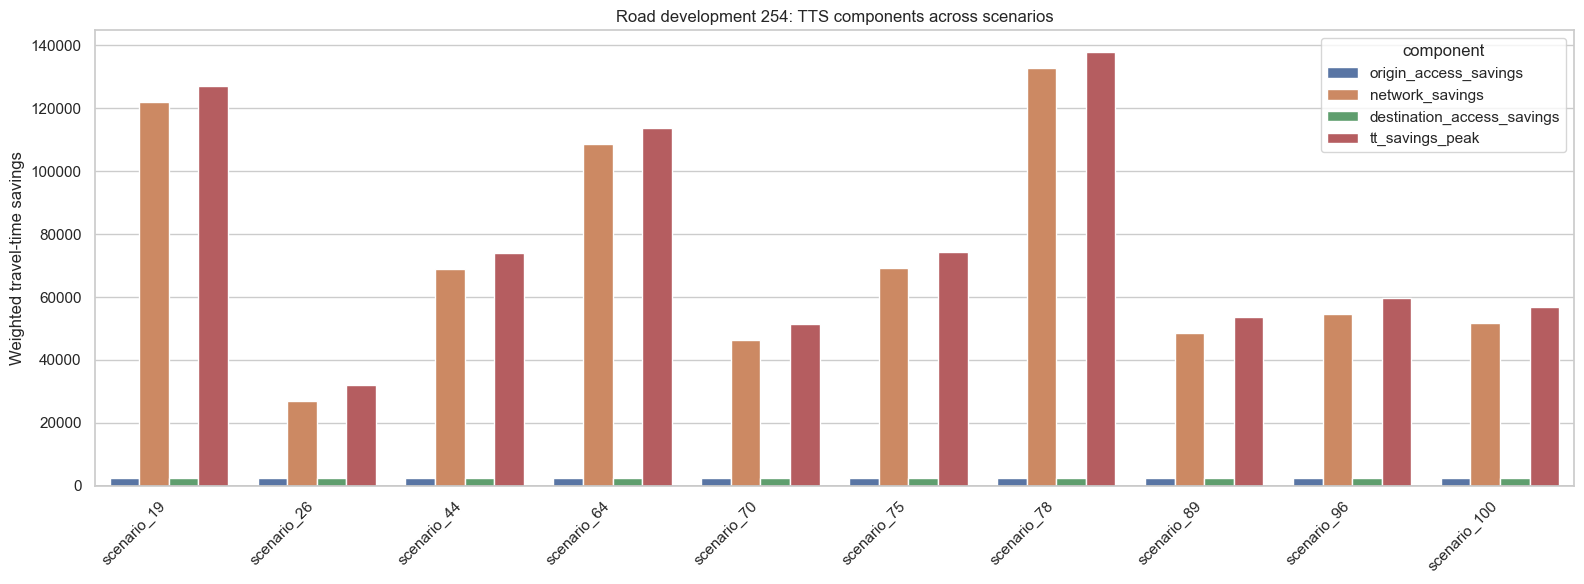

,development,scenario,tts_raw,tts_integrated,bcr_integrated,net_benefit_integrated,construction_raw,maintenance_raw,externalities_raw
142,15,scenario_19,"147,560,064.69","164,359,043.55",19.14,"155,770,855.16","195,150,622.91","2,534,637.65","244,570,297.76"
280,15,scenario_26,"30,198,882.45","33,636,874.89",3.92,"25,048,686.51","195,150,622.91","2,534,637.65","244,570,297.76"
418,15,scenario_44,"82,356,689.34","91,732,588.48",10.68,"83,144,400.09","195,150,622.91","2,534,637.65","244,570,297.76"
556,15,scenario_64,"130,900,613.00","145,802,996.21",16.98,"137,214,807.82","195,150,622.91","2,534,637.65","244,570,297.76"
694,15,scenario_70,"54,402,867.25","60,596,362.89",7.06,"52,008,174.50","195,150,622.91","2,534,637.65","244,570,297.76"
832,15,scenario_75,"82,706,258.39","92,121,954.22",10.73,"83,533,765.83","195,150,622.91","2,534,637.65","244,570,297.76"
970,15,scenario_78,"160,717,374.29","179,014,247.36",20.84,"170,426,058.97","195,150,622.91","2,534,637.65","244,570,297.76"
1108,15,scenario_89,"57,185,256.43","63,695,513.23",7.42,"55,107,324.84","195,150,622.91","2,534,637.65","244,570,297.76"
1246,15,scenario_96,"64,508,812.09","71,852,819.24",8.37,"63,264,630.85","195,150,622.91","2,534,637.65","244,570,297.76"
4,15,scenario_100,"61,152,727.66","68,114,661.31",7.93,"59,526,472.92","195,150,622.91","2,534,637.65","244,570,297.76"


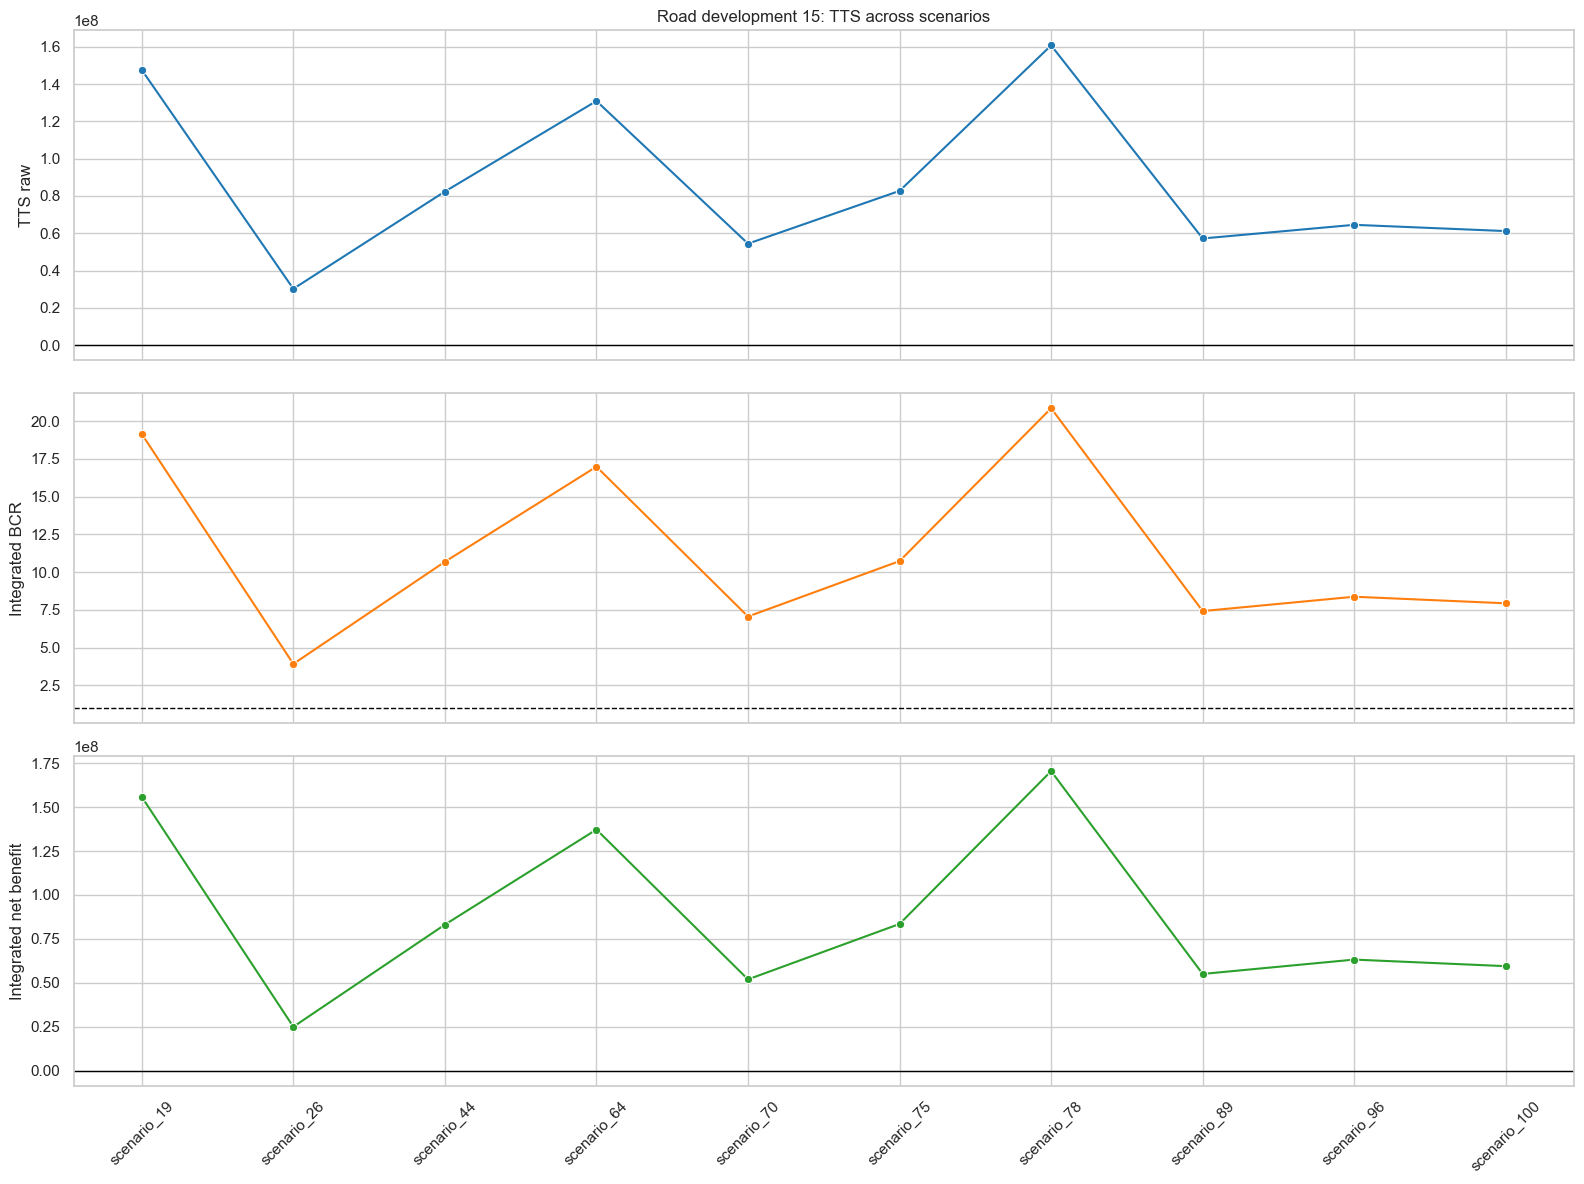

,development,scenario,origin_access_savings,network_savings,destination_access_savings,tt_savings_peak,monetized_savings
142,15,scenario_19,146.96,"10,984.56",146.96,"11,278.48","147,560,064.69"
280,15,scenario_26,146.96,"2,014.28",146.96,"2,308.19","30,198,882.45"
418,15,scenario_44,146.96,"6,000.86",146.96,"6,294.78","82,356,689.34"
556,15,scenario_64,146.96,"9,711.23",146.96,"10,005.14","130,900,613.00"
694,15,scenario_70,146.96,"3,864.26",146.96,"4,158.18","54,402,867.25"
832,15,scenario_75,146.96,"6,027.58",146.96,"6,321.50","82,706,258.39"
970,15,scenario_78,146.96,"11,990.21",146.96,"12,284.13","160,717,374.29"
1108,15,scenario_89,146.96,"4,076.93",146.96,"4,370.85","57,185,256.43"
1246,15,scenario_96,146.96,"4,636.69",146.96,"4,930.61","64,508,812.09"
4,15,scenario_100,146.96,"4,380.18",146.96,"4,674.09","61,152,727.66"


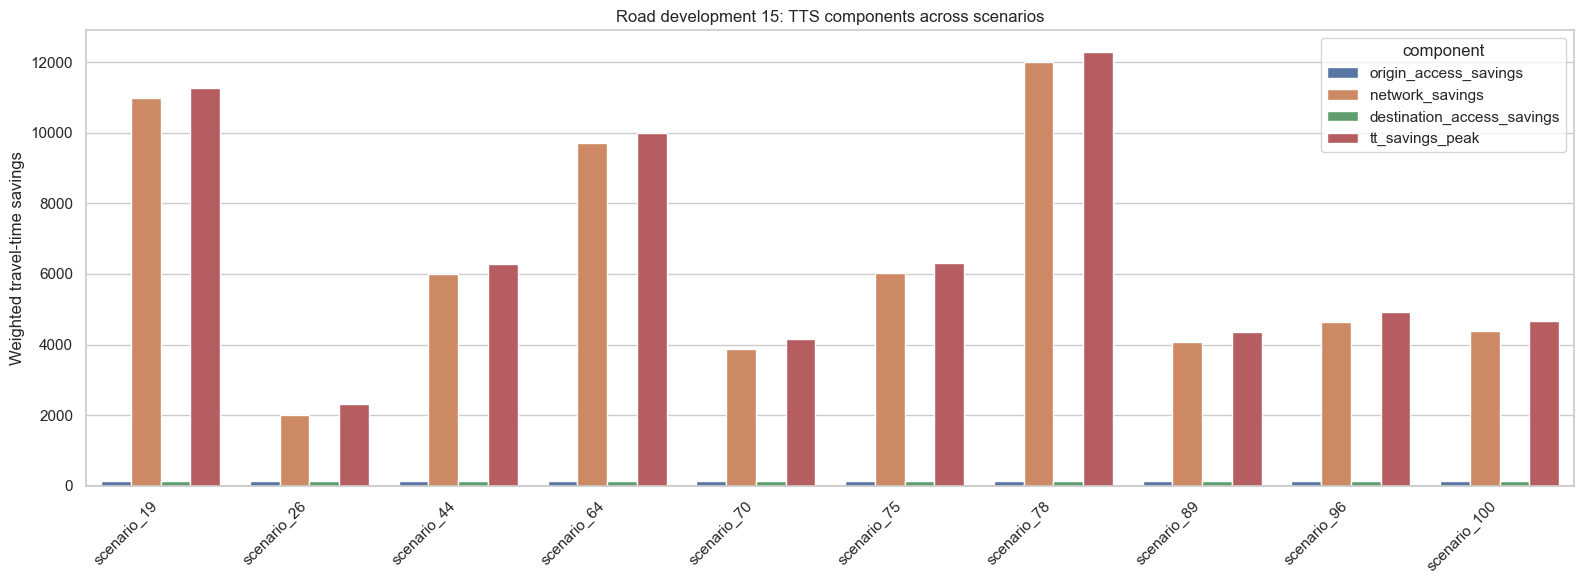

In [23]:
def plot_road_development_across_scenarios(development_id: str) -> None:
    development_id = str(development_id)
    road_subset = combined[(combined["mode"] == "Road") & (combined["development"].astype(str) == development_id)].copy()
    if road_subset.empty:
        print(f"No Road rows found for development {development_id}.")
        return

    road_subset["scenario_order"] = road_subset["scenario"].map(scenario_number)
    road_subset = road_subset.sort_values("scenario_order")

    display(
        road_subset[[
            "development",
            "scenario",
            "tts_raw",
            "tts_integrated",
            "bcr_integrated",
            "net_benefit_integrated",
            "construction_raw",
            "maintenance_raw",
            "externalities_raw",
        ]]
    )

    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    sns.lineplot(data=road_subset, x="scenario", y="tts_raw", marker="o", ax=axes[0], color="#1f77b4")
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title(f"Road development {development_id}: TTS across scenarios")
    axes[0].set_ylabel("TTS raw")

    sns.lineplot(data=road_subset, x="scenario", y="bcr_integrated", marker="o", ax=axes[1], color="#ff7f0e")
    axes[1].axhline(1, color="black", linewidth=1, linestyle="--")
    axes[1].set_ylabel("Integrated BCR")

    sns.lineplot(data=road_subset, x="scenario", y="net_benefit_integrated", marker="o", ax=axes[2], color="#2ca02c")
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_ylabel("Integrated net benefit")
    axes[2].set_xlabel("")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    if "road_tts_detailed" in globals() and road_tts_detailed is not None:
        detail_subset = road_tts_detailed[road_tts_detailed["development"].astype(str) == development_id].copy()
        if not detail_subset.empty:
            detail_subset["scenario_order"] = detail_subset["scenario"].map(scenario_number)
            detail_subset = detail_subset.sort_values("scenario_order")
            display(
                detail_subset[[
                    "development",
                    "scenario",
                    "origin_access_savings",
                    "network_savings",
                    "destination_access_savings",
                    "tt_savings_peak",
                    "monetized_savings",
                ]]
            )

            detail_plot = detail_subset.melt(
                id_vars=["development", "scenario"],
                value_vars=[
                    "origin_access_savings",
                    "network_savings",
                    "destination_access_savings",
                    "tt_savings_peak",
                ],
                var_name="component",
                value_name="value",
            )

            plt.figure(figsize=(16, 6))
            sns.barplot(data=detail_plot, x="scenario", y="value", hue="component")
            plt.axhline(0, color="black", linewidth=1)
            plt.title(f"Road development {development_id}: TTS components across scenarios")
            plt.ylabel("Weighted travel-time savings")
            plt.xlabel("")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()
        else:
            print(f"No detailed TTS decomposition found for development {development_id}.")


for development_id in ["254", "15"]:
    plot_road_development_across_scenarios(development_id)


In [24]:
import importlib
from infraScan.infraScanIntegrated import sensitivity_analysis as sa
importlib.reload(sa)

<module 'infraScan.infraScanIntegrated.sensitivity_analysis' from '/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanIntegrated/sensitivity_analysis.py'>

/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanIntegrated/sensitivity_analysis.py:821: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.91, 0.97))


,mode,pct_ratio_change_per_1pct_vtt_change
0,Rail,1.00
1,Road,1.00


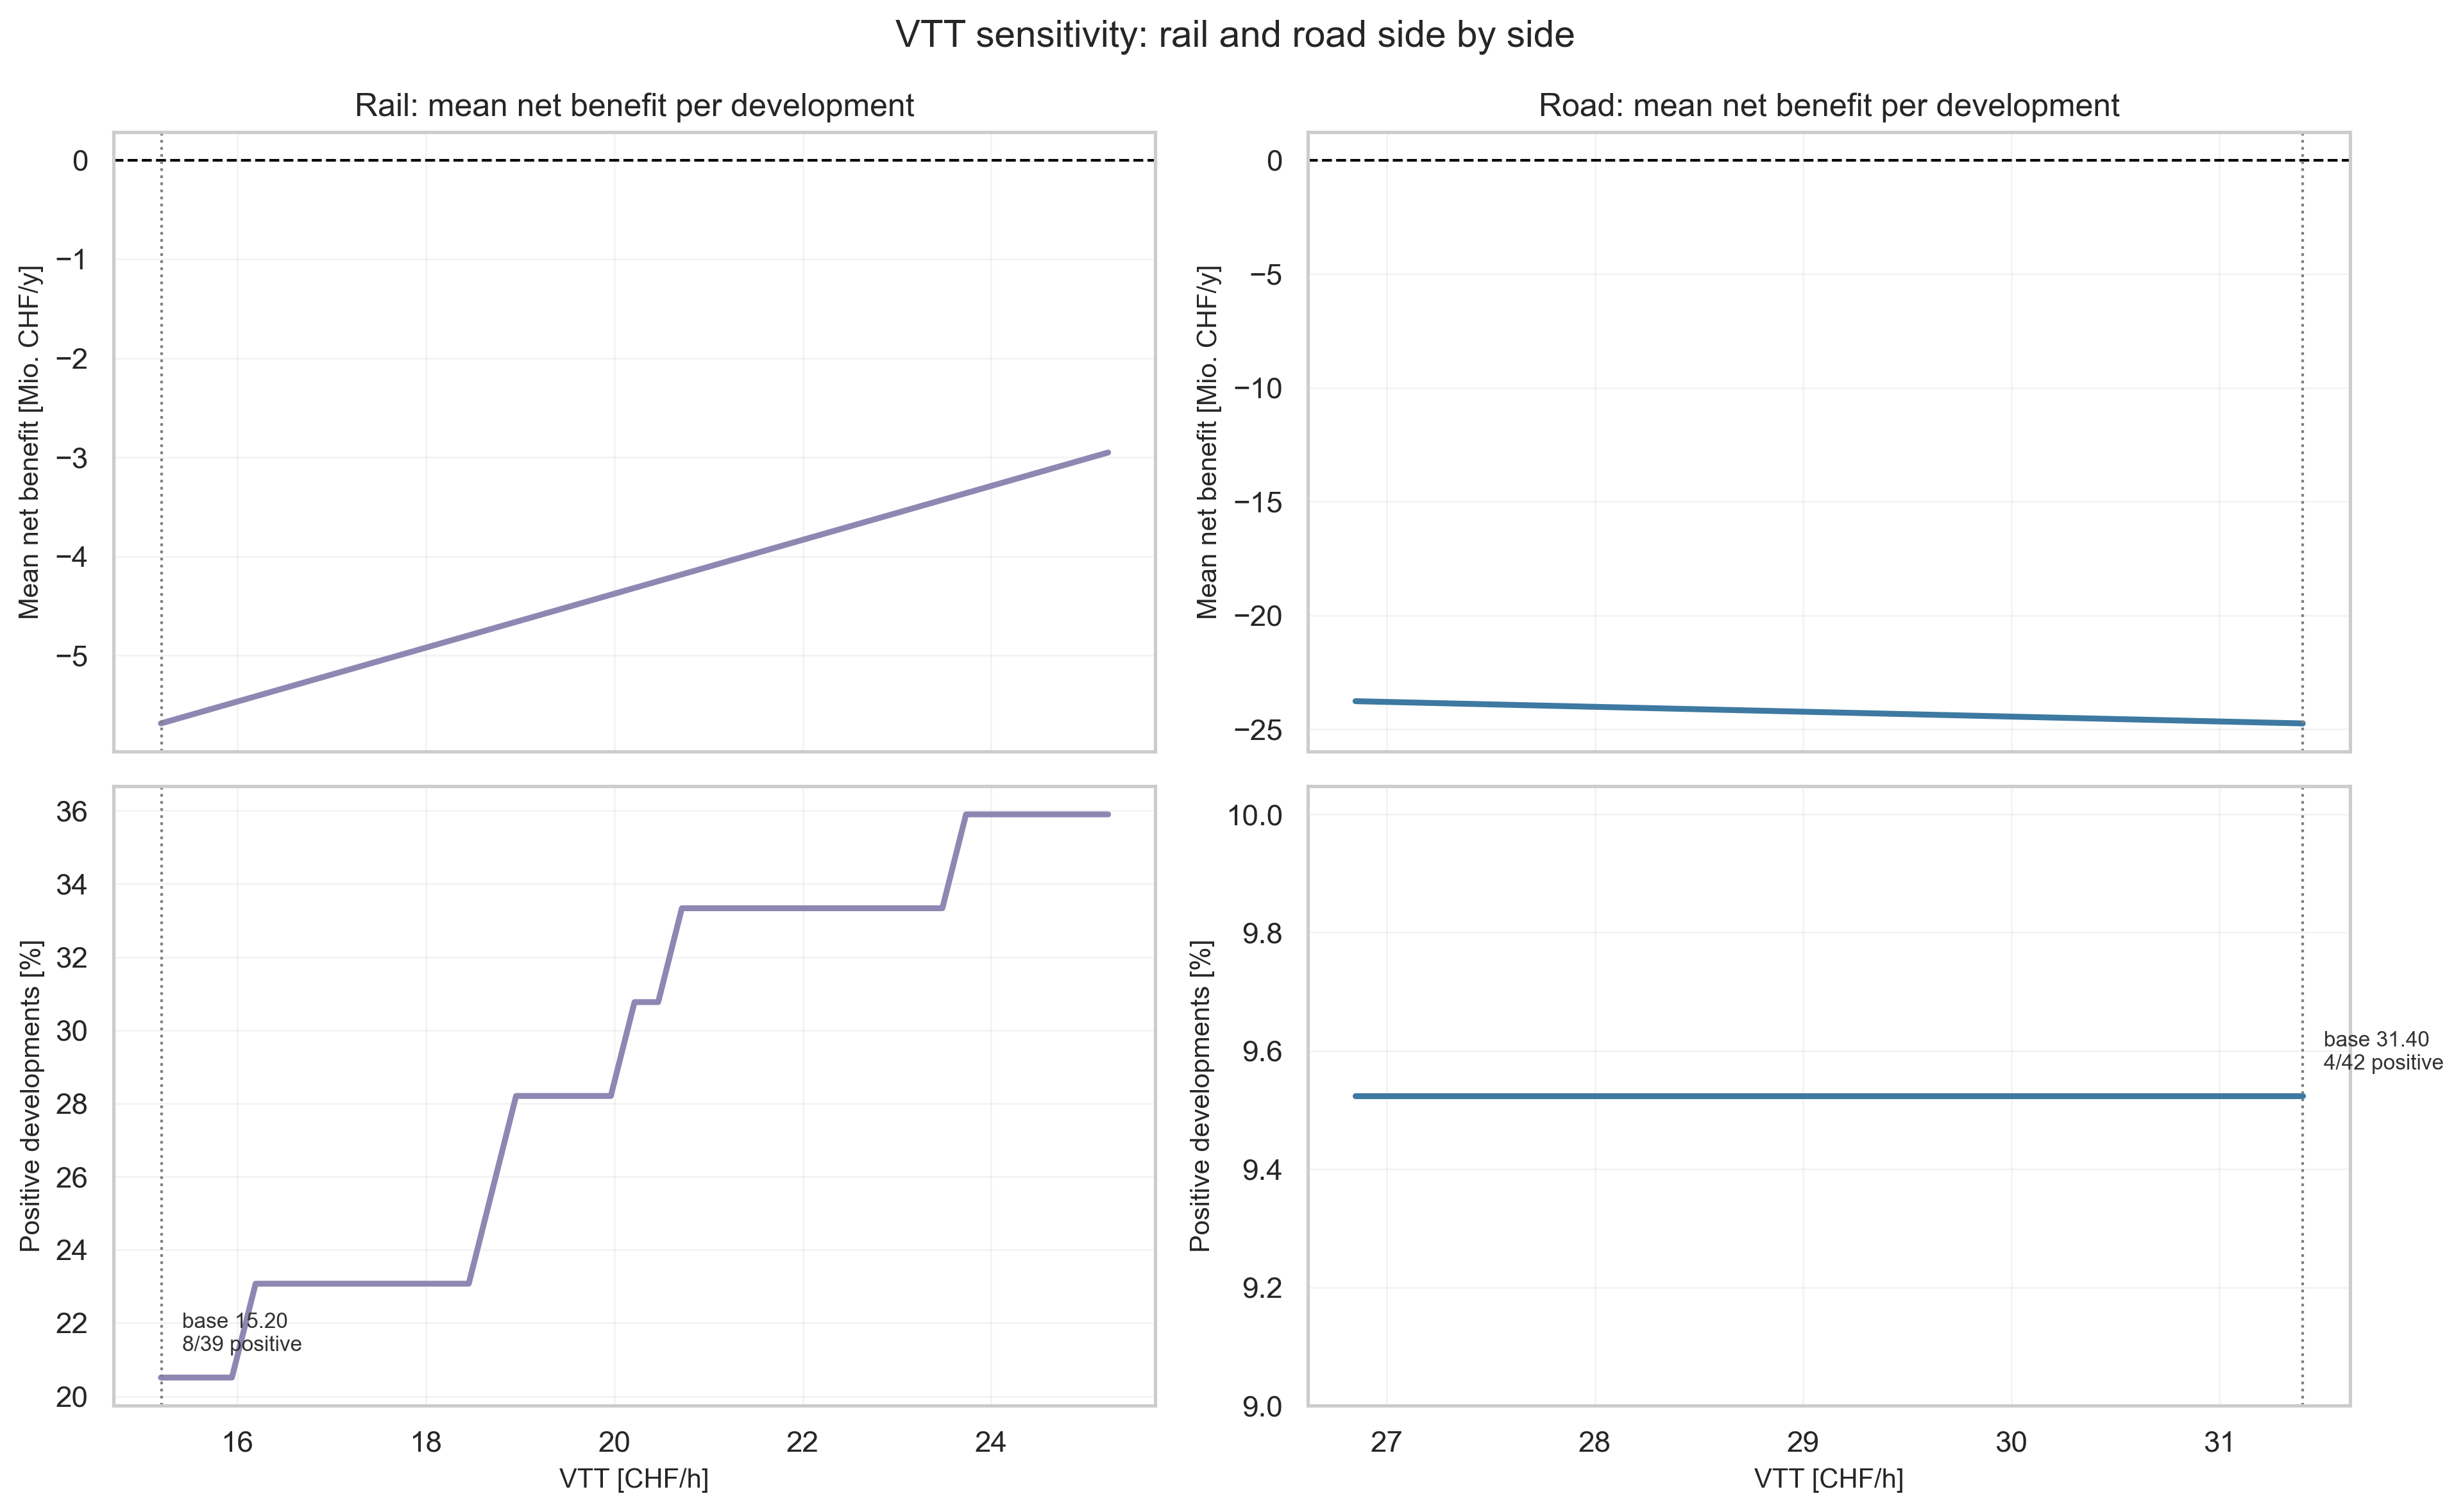

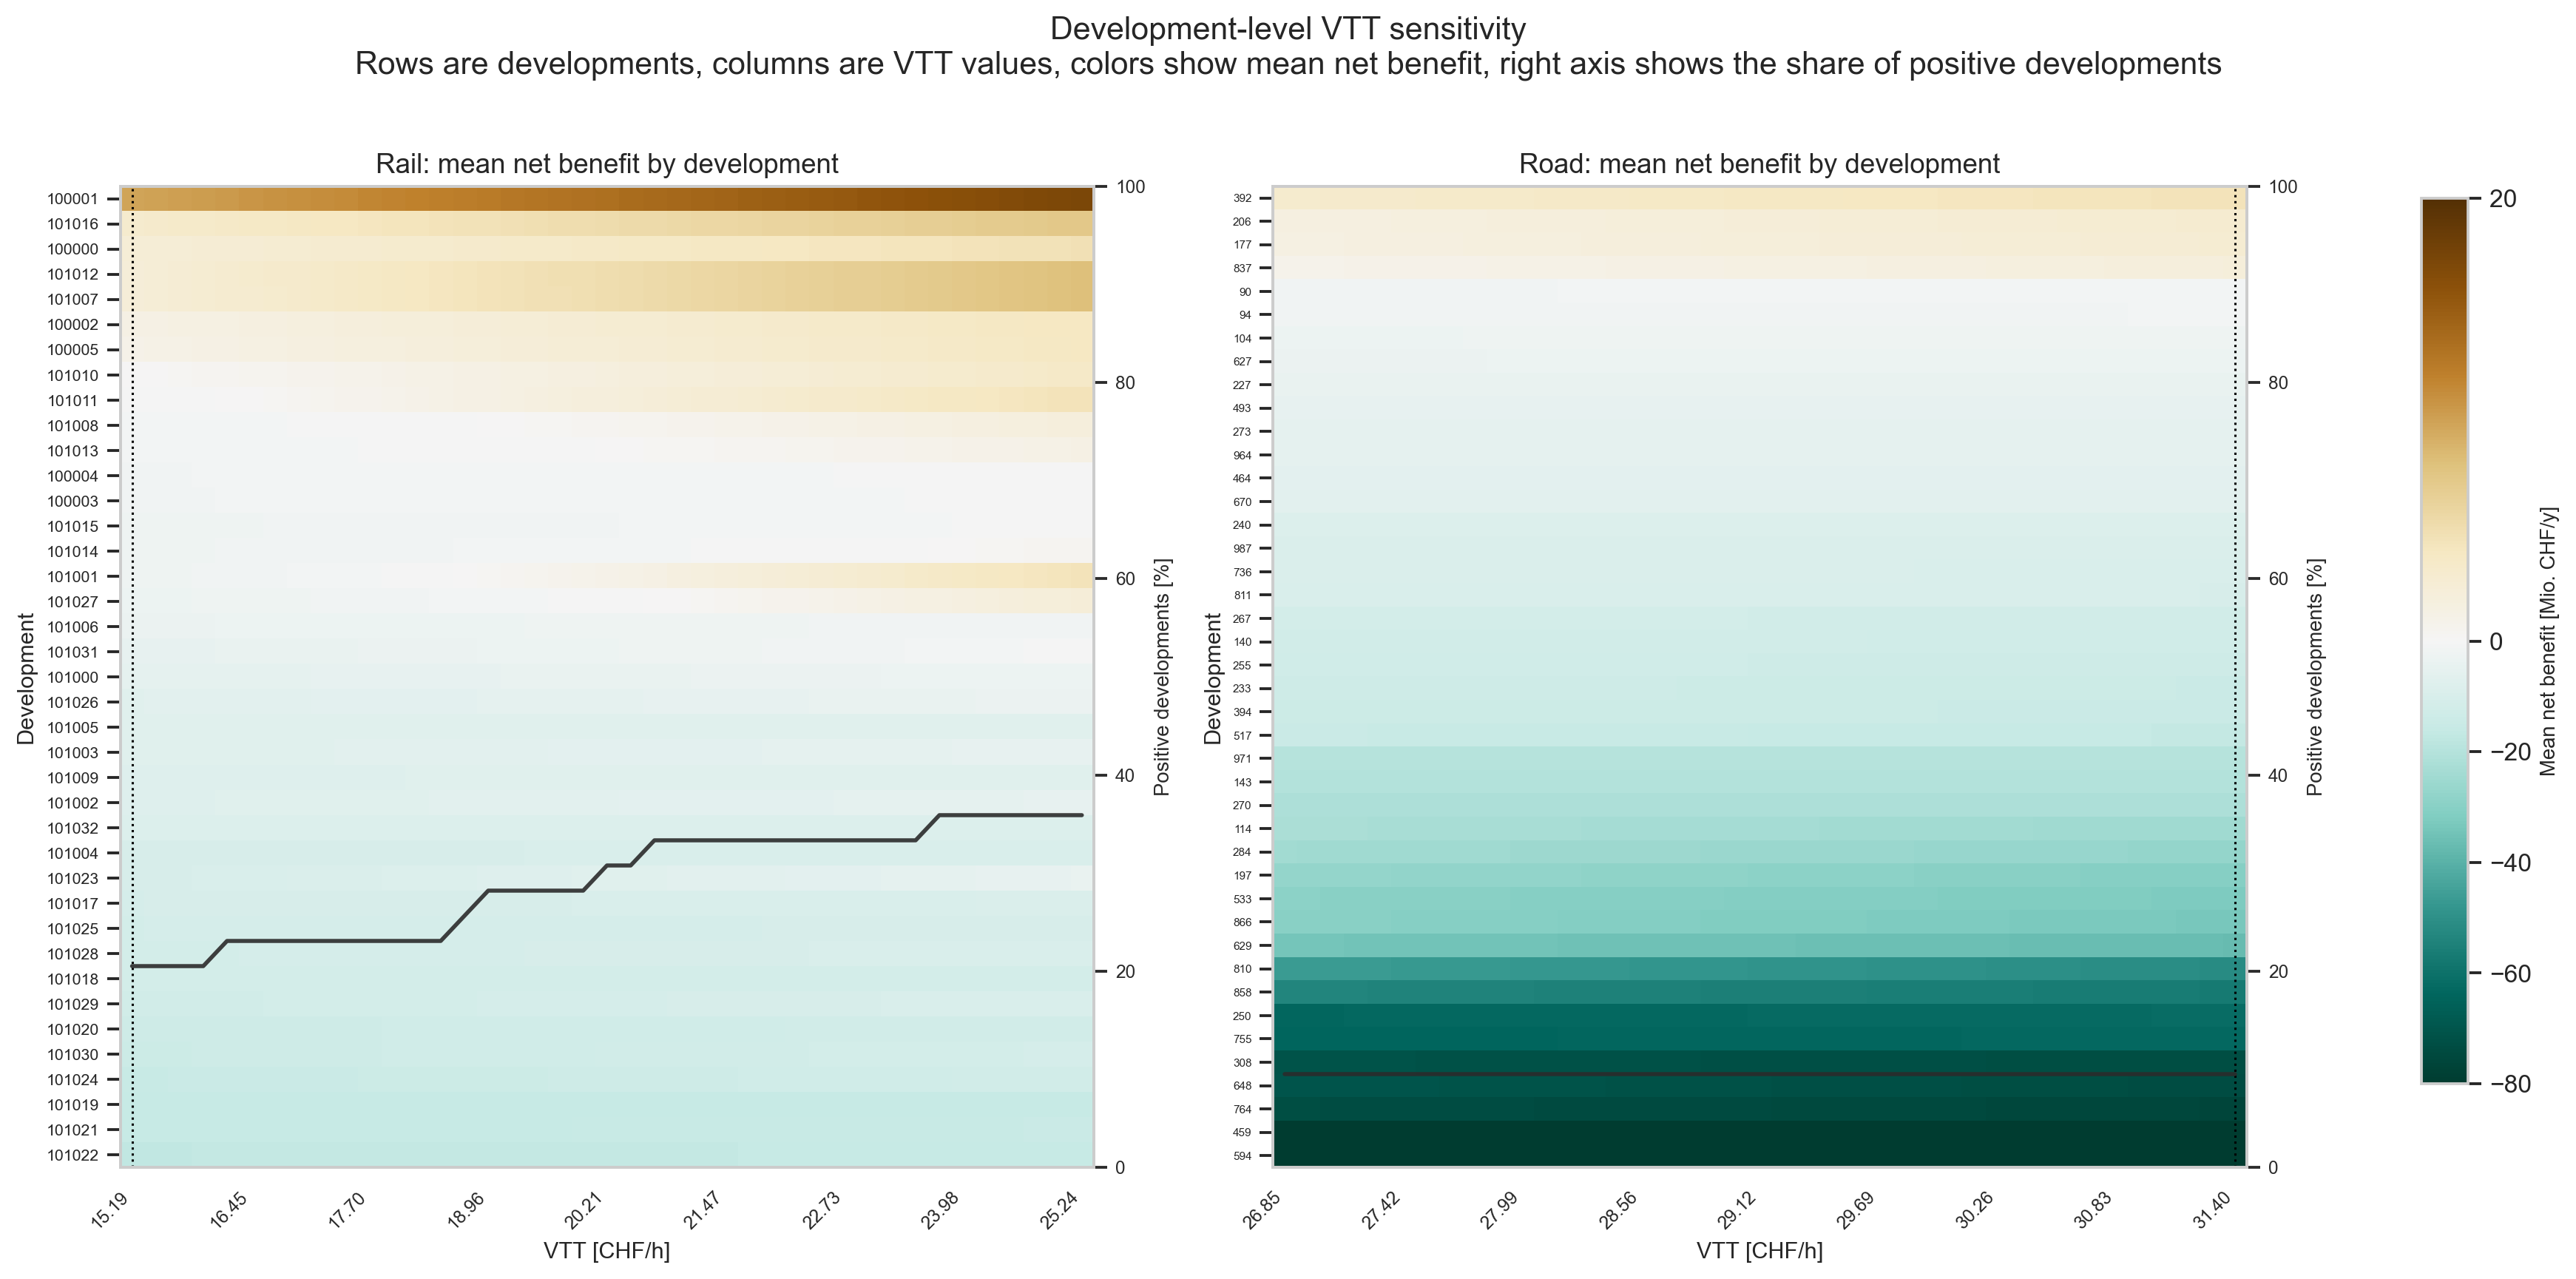

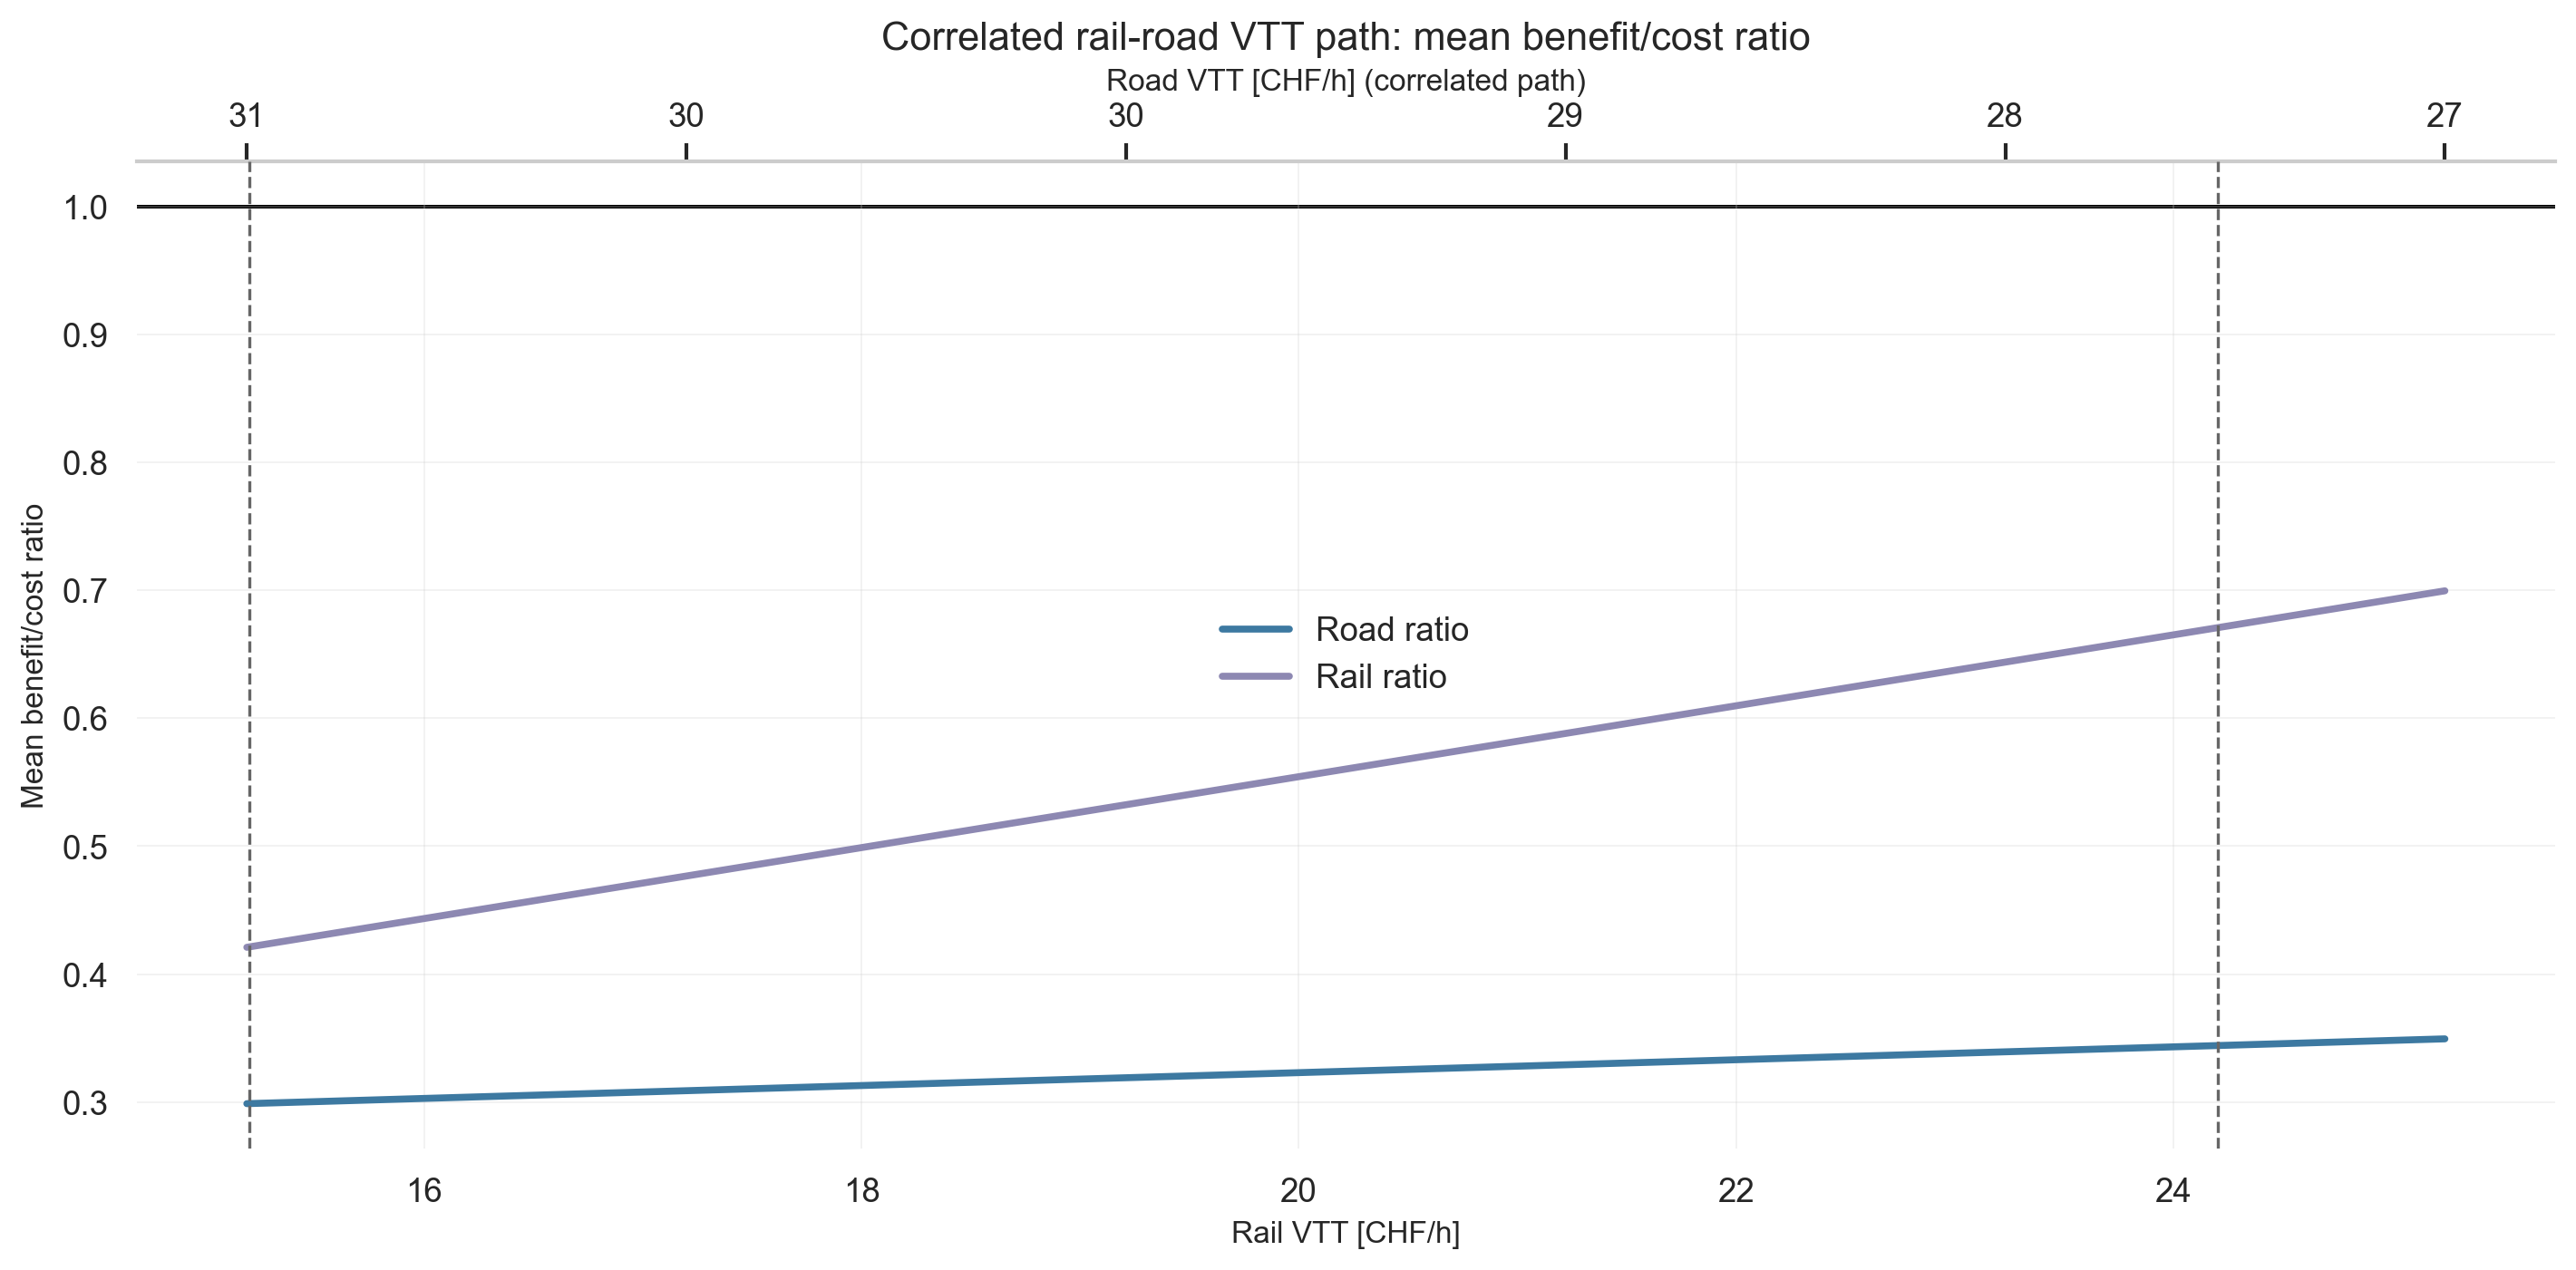

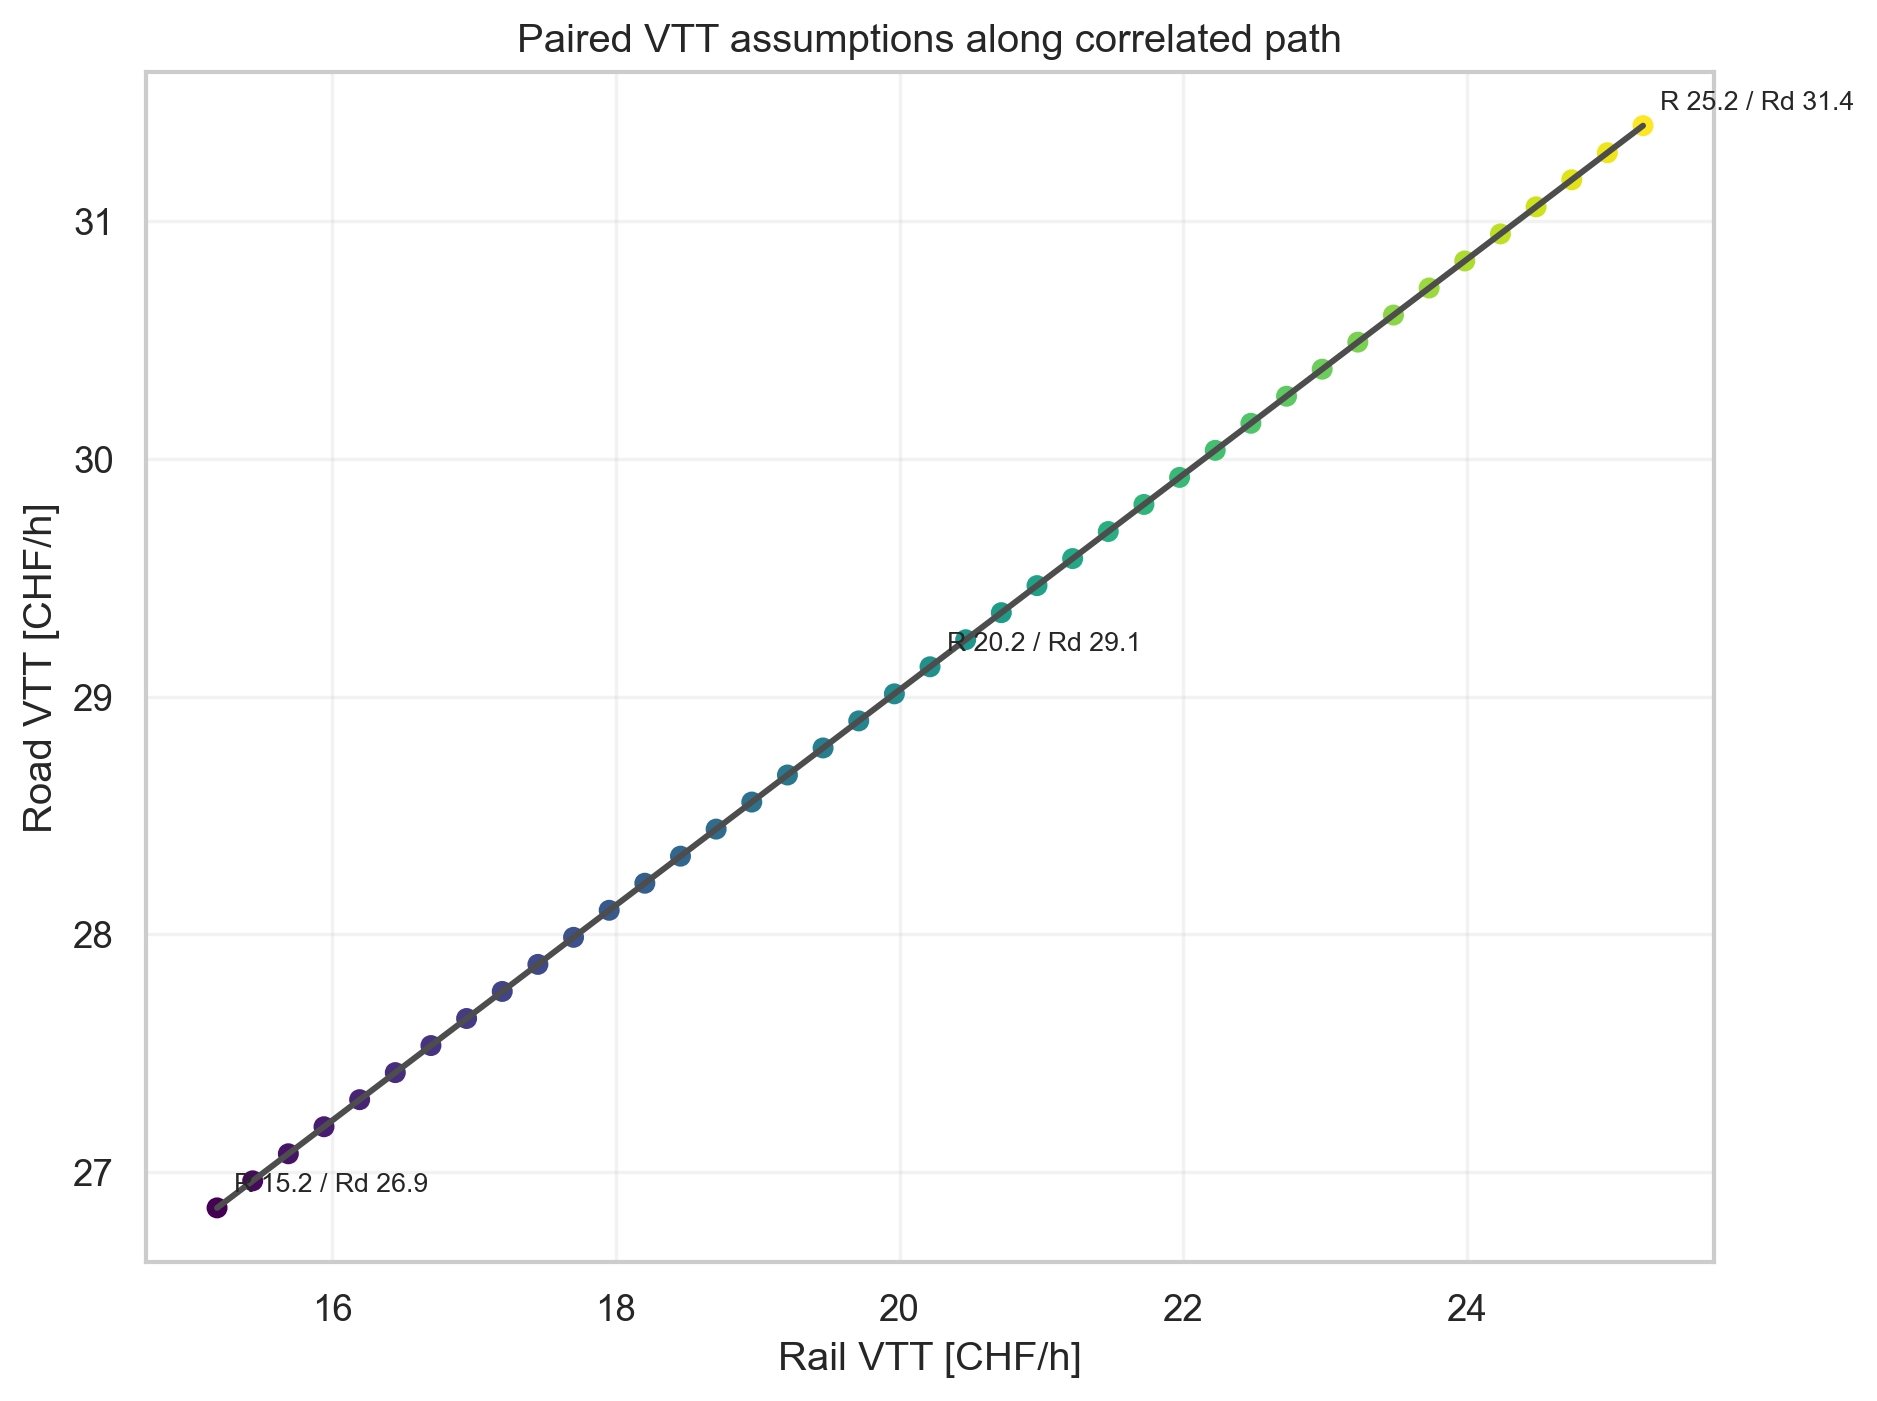

In [25]:
from pathlib import Path
import pandas as pd

from infraScan.infraScanIntegrated import sensitivity_analysis as sa

analysis_df = analysis_df.copy()

output_dir = workspace_root / "infraScan" / "output_directory"
output_dir.mkdir(parents=True, exist_ok=True)

grid_size = 41
top_road_developments = 40

summary_df = pd.concat(
    [
        sa.summarize_mode(analysis_df, "Rail", grid_size),
        sa.summarize_mode(analysis_df, "Road", grid_size),
    ],
    ignore_index=True,
)

development_df = pd.concat(
    [
        sa.summarize_mode_by_development(analysis_df, "Rail", grid_size),
        sa.summarize_mode_by_development(analysis_df, "Road", grid_size),
    ],
    ignore_index=True,
)

correlated_df = sa.build_correlated_surface(summary_df)
correlated_ratio_df = sa.summarize_ratio_line_correlated(analysis_df, grid_size)

road_base_vtt = float(sa.MODE_CONFIG["Road"]["base_vtt"])
road_base_candidates = np.sort(development_df.loc[development_df["mode"] == "Road", "vtt_chf_per_hour"].unique())
road_base_vtt_nearest = float(road_base_candidates[np.argmin(np.abs(road_base_candidates - road_base_vtt))])
road_dev_summary = (
    development_df[
        (development_df["mode"] == "Road")
        & (np.isclose(development_df["vtt_chf_per_hour"], road_base_vtt_nearest))
    ]
    .sort_values("mean_net_benefit", ascending=False)
    .copy()
)
top_road_ids = road_dev_summary["development"].astype(int).drop_duplicates().head(top_road_developments).tolist()

summary_df.to_csv(output_dir / "vtt_sensitivity_summary_selected_filtered.csv", index=False)
development_df.to_csv(output_dir / "vtt_sensitivity_development_summary_selected_filtered.csv", index=False)
correlated_df.to_csv(output_dir / "vtt_sensitivity_correlated_selected_filtered.csv", index=False)
correlated_ratio_df.to_csv(output_dir / "vtt_sensitivity_correlated_ratio_lines_selected_filtered.csv", index=False)
sa.build_normalized_correlated_ratio_df(correlated_ratio_df).to_csv(
    output_dir / "vtt_sensitivity_correlated_ratio_lines_normalized_selected_filtered.csv",
    index=False,
)
pd.DataFrame({"development": top_road_ids}).to_csv(
    output_dir / "vtt_sensitivity_road_top40_selected_filtered.csv",
    index=False,
)

sa.plot_side_by_side(
    summary_df,
    output_dir / "vtt_sensitivity_side_by_side_selected_filtered.png",
)


sa.plot_development_heatmaps(
    development_df,
    output_dir / "vtt_sensitivity_development_heatmaps_selected_filtered.png",
)


sa.plot_selected_correlated_ratio_lines(
    correlated_ratio_df,
    output_dir / "vtt_sensitivity_correlated_ratio_lines_selected_filtered.png",
)


normalized_ratio_df = sa.build_normalized_correlated_ratio_df(correlated_ratio_df)

rail_slope = np.polyfit(
    normalized_ratio_df["rail_vtt_pct_change"],
    normalized_ratio_df["rail_ratio_pct_change"],
    1,
)[0]

road_slope = np.polyfit(
    normalized_ratio_df["road_vtt_pct_change"],
    normalized_ratio_df["road_ratio_pct_change"],
    1,
)[0]

elasticity_summary = pd.DataFrame(
    {
        "mode": ["Rail", "Road"],
        "pct_ratio_change_per_1pct_vtt_change": [rail_slope, road_slope],
    }
)

display(elasticity_summary)

paired_vtt_df = correlated_ratio_df.copy()

fig, ax = plt.subplots(figsize=(8, 6), dpi=240)

ax.plot(
    paired_vtt_df["vtt_chf_per_hour_rail"],
    paired_vtt_df["vtt_chf_per_hour_road"],
    color="#4d4d4d",
    linewidth=1.8,
)

ax.scatter(
    paired_vtt_df["vtt_chf_per_hour_rail"],
    paired_vtt_df["vtt_chf_per_hour_road"],
    c=np.arange(len(paired_vtt_df)),
    cmap="viridis",
    s=28,
)

highlight_idx = [0, len(paired_vtt_df) // 2, len(paired_vtt_df) - 1]
for idx in highlight_idx:
    row = paired_vtt_df.iloc[idx]
    ax.annotate(
        f"R {row['vtt_chf_per_hour_rail']:.1f} / Rd {row['vtt_chf_per_hour_road']:.1f}",
        (row["vtt_chf_per_hour_rail"], row["vtt_chf_per_hour_road"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Rail VTT [CHF/h]")
ax.set_ylabel("Road VTT [CHF/h]")
ax.set_title("Paired VTT assumptions along correlated path")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()



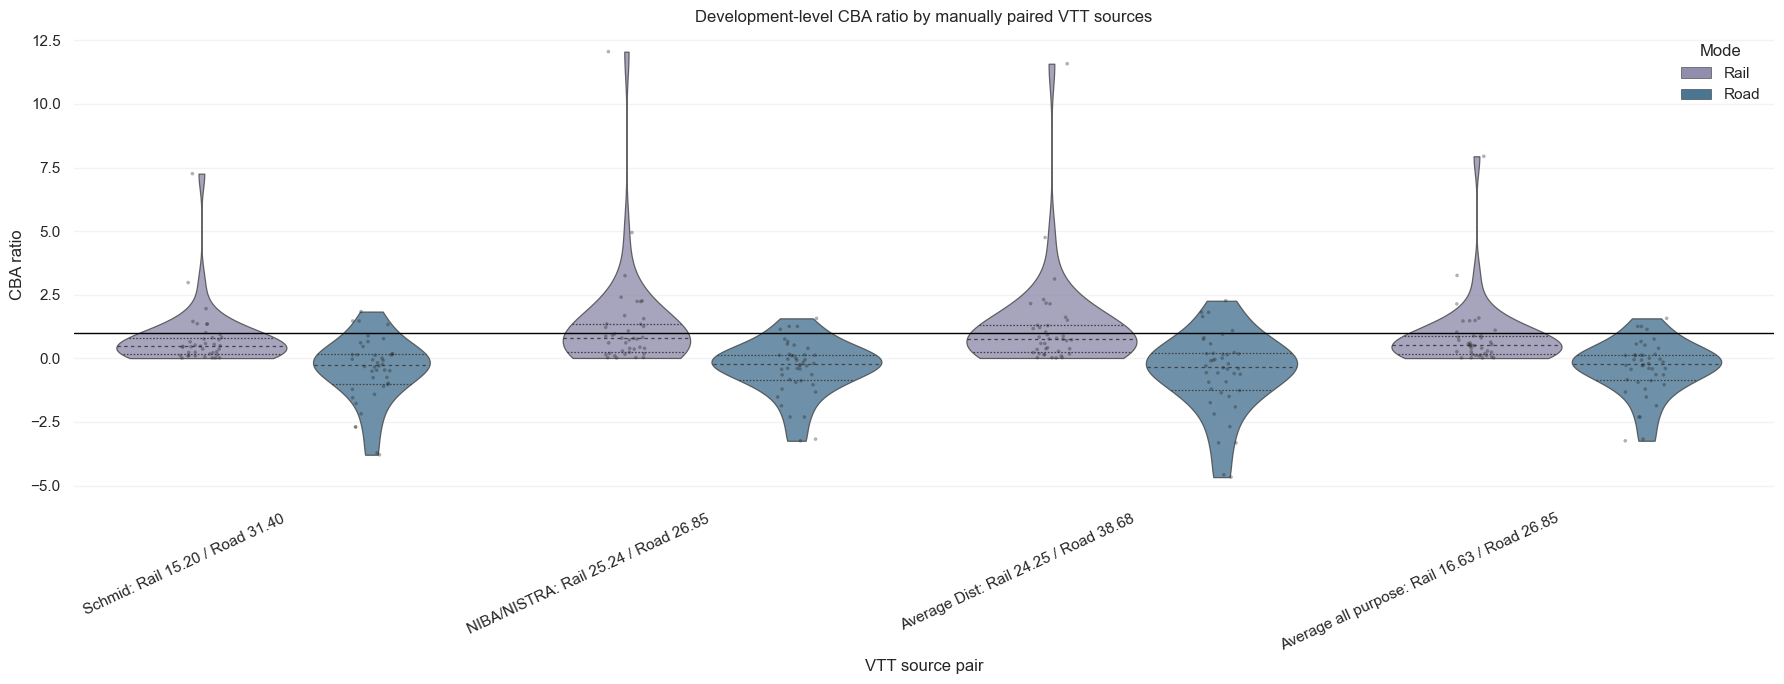

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

source_pairs = pd.DataFrame(
    [
        {"source": "Schmid", "rail_vtt": 15.2,  "road_vtt": 31.4},
        {"source": "NIBA/NISTRA", "rail_vtt": 25.24, "road_vtt": 26.85},
        {"source": "Average Dist", "rail_vtt": 24.25, "road_vtt": 38.68},
        {"source": "Average all purpose", "rail_vtt": 16.63, "road_vtt": 26.85},
    ]
)
source_pairs["label"] = source_pairs.apply(
    lambda row: f"{row['source']}: Rail {row['rail_vtt']:.2f} / Road {row['road_vtt']:.2f}",
    axis=1,
)

ratio_rows = []

for row in source_pairs.itertuples(index=False):
    rail_base = analysis_df[analysis_df["mode"] == "Rail"].copy()
    road_base = analysis_df[analysis_df["mode"] == "Road"].copy()

    rail_base["adjusted_tts"] = rail_base["tts_integrated"] * (row.rail_vtt / sa.MODE_CONFIG["Rail"]["base_vtt"])
    rail_base["adjusted_ratio"] = rail_base["adjusted_tts"] / rail_base["cost_base_integrated"]

    road_base["adjusted_tts"] = road_base["tts_integrated"] * (row.road_vtt / sa.MODE_CONFIG["Road"]["base_vtt"])
    road_base["adjusted_ratio"] = road_base["adjusted_tts"] / road_base["cost_base_integrated"]

    ratio_rows.append(
        rail_base.groupby("development", as_index=False)["adjusted_ratio"].mean()
        .assign(mode="Rail", source=row.source, label=row.label)
    )
    ratio_rows.append(
        road_base.groupby("development", as_index=False)["adjusted_ratio"].mean()
        .assign(mode="Road", source=row.source, label=row.label)
    )

ratio_plot_df = pd.concat(ratio_rows, ignore_index=True)
ratio_plot_df["label"] = pd.Categorical(
    ratio_plot_df["label"],
    categories=source_pairs["label"].tolist(),
    ordered=True,
)

palette = {"Rail": "#8D88B2", "Road": "#3D79A1"}

fig, ax = plt.subplots(figsize=(18, 7))

sns.violinplot(
    data=ratio_plot_df,
    x="label",
    y="adjusted_ratio",
    hue="mode",
    palette=palette,
    cut=0,
    inner="quartile",
    linewidth=0.9,
    dodge=True,
    ax=ax,
)

for collection in ax.collections:
    collection.set_alpha(0.8)

sns.stripplot(
    data=ratio_plot_df,
    x="label",
    y="adjusted_ratio",
    hue="mode",
    dodge=True,
    jitter=0.10,
    alpha=0.35,
    size=2.6,
    palette={"Rail": "#212121", "Road": "#212121"},
    zorder=5,
    ax=ax,
)

ax.axhline(1, color="black", linewidth=1, linestyle="-")
ax.set_title("Development-level CBA ratio by manually paired VTT sources")
ax.set_xlabel("VTT source pair")
ax.set_ylabel("CBA ratio")
plt.xticks(rotation=25, ha="right")

# Deduplicate legend entries from violin + strip
handles, labels = ax.get_legend_handles_labels()
seen = set()
filtered_handles = []
filtered_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        filtered_handles.append(h)
        filtered_labels.append(l)
        seen.add(l)

ax.legend(filtered_handles[:2], filtered_labels[:2], title="Mode", frameon=False)
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
rail_all = pd.read_csv(RAIL_TTS_CSV).copy()
rail_all["development"] = normalize_development(rail_all["development"])
rail_all["year"] = pd.to_numeric(rail_all["year"], errors="coerce")

available_years = sorted(rail_all["year"].dropna().astype(int).unique().tolist())
rail_year = common_cost_parameters.prognosis_year if common_cost_parameters.prognosis_year in available_years else max(available_years)
rail_all = rail_all[rail_all["year"] == rail_year].copy()

rail_construction_raw = pd.read_csv(RAIL_CONSTRUCTION_CSV)
rail_construction_registry_input = rail_construction_raw.rename(columns={
    "Development": "ID_new",
    "TotalConstructionCost": "building_costs",
}).copy()

all_rail_scenarios = sorted(rail_all["scenario"].astype(str).unique().tolist())

rail_construction_scores = score_result_to_frame(
    registry.build_rail_construction_result_df(rail_construction_registry_input, all_rail_scenarios),
    "rail_construction_cost",
    "construction_raw",
    "construction_integrated",
)

rail_static_registry = rail_construction_raw.rename(columns={"Development": "ID_new"}).copy()
rail_maint_scores = score_result_to_frame(
    registry.build_rail_maint_result_df(rail_static_registry, all_rail_scenarios),
    "rail_maint_cost",
    "maintenance_raw",
    "maintenance_integrated",
)
rail_op_scores = score_result_to_frame(
    registry.build_rail_operation_result_df(rail_static_registry, all_rail_scenarios),
    "rail_operation_cost",
    "operation_raw",
    "operation_integrated",
)

rail_tts_scores = score_result_to_frame(
    registry.build_rail_tts_result_df(rail_all.copy()),
    "rail_tts_cost",
    "tts_raw",
    "tts_integrated",
)

rail_all_base = rail_all.merge(rail_construction_scores, on=["development", "scenario"], how="left")
rail_all_base = rail_all_base.merge(rail_maint_scores, on=["development", "scenario"], how="left")
rail_all_base = rail_all_base.merge(rail_op_scores, on=["development", "scenario"], how="left")
rail_all_base = rail_all_base.merge(rail_tts_scores, on=["development", "scenario"], how="left")

rail_all_base["cost_base_integrated"] = rail_all_base[
    ["construction_integrated", "maintenance_integrated", "operation_integrated"]
].sum(axis=1)
rail_all_base["mode"] = "Rail"

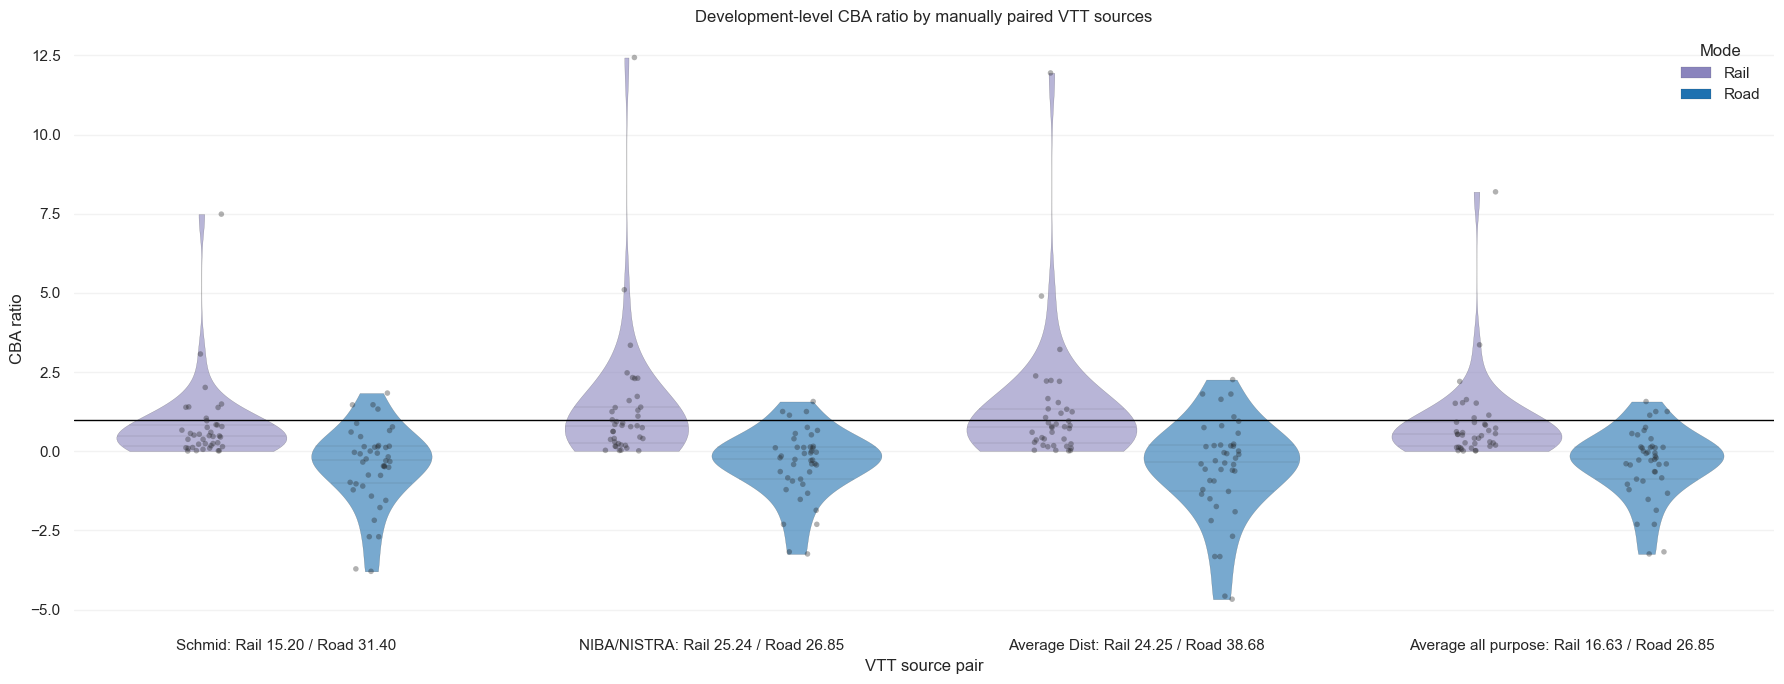

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

source_pairs = pd.DataFrame(
    [
        {"source": "Schmid", "rail_vtt": 15.2,  "road_vtt": 31.4},
        {"source": "NIBA/NISTRA", "rail_vtt": 25.24, "road_vtt": 26.85},
        {"source": "Average Dist", "rail_vtt": 24.25, "road_vtt": 38.68},
        {"source": "Average all purpose", "rail_vtt": 16.63, "road_vtt": 26.85},
    ]
)
source_pairs["label"] = source_pairs.apply(
    lambda row: f"{row['source']}: Rail {row['rail_vtt']:.2f} / Road {row['road_vtt']:.2f}",
    axis=1,
)

# Rail: all scenarios
rail_base = rail_all_base.copy()

# Road: only the 10 scenarios in analysis_df
road_base = analysis_df[analysis_df["mode"] == "Road"].copy()

ratio_rows = []

for row in source_pairs.itertuples(index=False):
    rail_work = rail_base.copy()
    rail_work["adjusted_tts"] = (
        rail_work["tts_integrated"] * (row.rail_vtt / sa.MODE_CONFIG["Rail"]["base_vtt"])
    )
    rail_work["adjusted_ratio"] = rail_work["adjusted_tts"] / rail_work["cost_base_integrated"]

    rail_dev = (
        rail_work.groupby("development", as_index=False)["adjusted_ratio"]
        .mean()
        .assign(mode="Rail", source=row.source, label=row.label)
    )
    ratio_rows.append(rail_dev)

    road_work = road_base.copy()
    road_work["adjusted_tts"] = (
        road_work["tts_integrated"] * (row.road_vtt / sa.MODE_CONFIG["Road"]["base_vtt"])
    )
    road_work["adjusted_ratio"] = road_work["adjusted_tts"] / road_work["cost_base_integrated"]

    road_dev = (
        road_work.groupby("development", as_index=False)["adjusted_ratio"]
        .mean()
        .assign(mode="Road", source=row.source, label=row.label)
    )
    ratio_rows.append(road_dev)

ratio_plot_df = pd.concat(ratio_rows, ignore_index=True)
ratio_plot_df["label"] = pd.Categorical(
    ratio_plot_df["label"],
    categories=source_pairs["label"].tolist(),
    ordered=True,
)

palette = {"Rail": "#837AC7", "Road": "#0674C8"}

fig, ax = plt.subplots(figsize=(18, 7))

sns.violinplot(
    data=ratio_plot_df,
    x="label",
    y="adjusted_ratio",
    hue="mode",
    palette=palette,
    cut=0,
    inner="quartile",
    linewidth=0.2,
    dodge=True,
    ax=ax,
)

for collection in ax.collections:
    collection.set_alpha(0.6)

sns.stripplot(
    data=ratio_plot_df,
    x="label",
    y="adjusted_ratio",
    hue="mode",
    dodge=True,
    jitter=0.10,
    alpha=0.35,
    size=4,
    palette={"Rail": "#212121", "Road": "#212121"},
    zorder=5,
    ax=ax,
)

ax.axhline(1, color="black", linewidth=1, linestyle="-")
ax.set_title("Development-level CBA ratio by manually paired VTT sources")
ax.set_xlabel("VTT source pair")
ax.set_ylabel("CBA ratio")
plt.xticks(ha="center")

handles, labels = ax.get_legend_handles_labels()
seen = set()
filtered_handles = []
filtered_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        filtered_handles.append(h)
        filtered_labels.append(l)
        seen.add(l)

ax.legend(filtered_handles[:2], filtered_labels[:2], title="Mode", frameon=False)
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

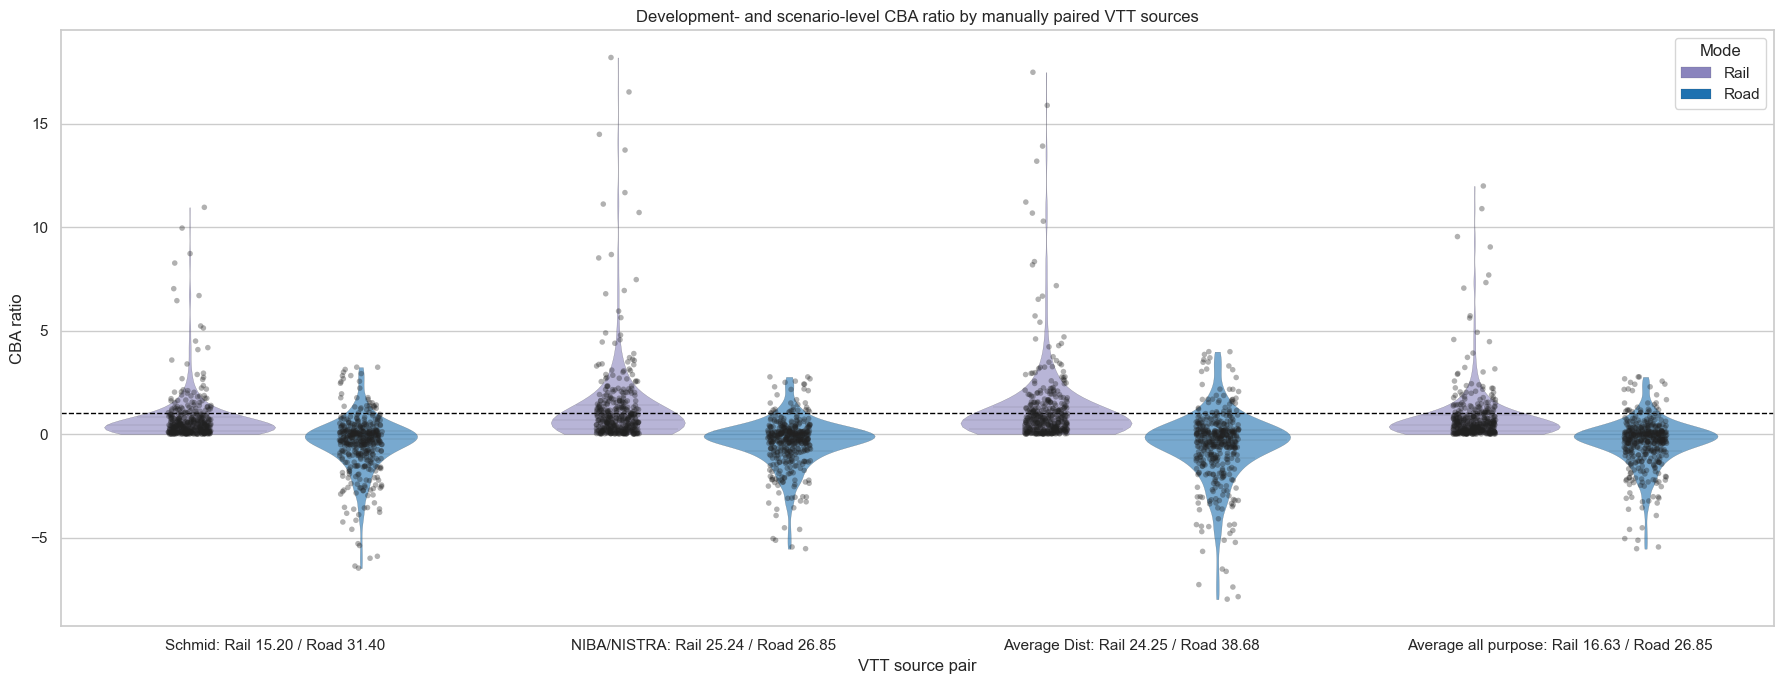

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# PRO DEV UNS SCENARIO EIN WERT

source_pairs = pd.DataFrame(
    [
        {"source": "Schmid", "rail_vtt": 15.2,  "road_vtt": 31.4},
        {"source": "NIBA/NISTRA", "rail_vtt": 25.24, "road_vtt": 26.85},
        {"source": "Average Dist", "rail_vtt": 24.25, "road_vtt": 38.68},
        {"source": "Average all purpose", "rail_vtt": 16.63, "road_vtt": 26.85},
    ]
)
source_pairs["label"] = source_pairs.apply(
    lambda row: f"{row['source']}: Rail {row['rail_vtt']:.2f} / Road {row['road_vtt']:.2f}",
    axis=1,
)

# Use all Rail rows available in analysis_df
rail_base = analysis_df[analysis_df["mode"] == "Rail"].copy()

# Use only the 10 Road scenarios currently in analysis_df
road_base = analysis_df[analysis_df["mode"] == "Road"].copy()

ratio_rows = []

for row in source_pairs.itertuples(index=False):
    rail_work = rail_base.copy()
    rail_work["adjusted_tts"] = (
        rail_work["tts_integrated"] * (row.rail_vtt / sa.MODE_CONFIG["Rail"]["base_vtt"])
    )
    rail_work["adjusted_ratio"] = rail_work["adjusted_tts"] / rail_work["cost_base_integrated"]
    rail_work["source"] = row.source
    rail_work["label"] = row.label
    ratio_rows.append(rail_work[["development", "scenario", "mode", "adjusted_ratio", "source", "label"]])

    road_work = road_base.copy()
    road_work["adjusted_tts"] = (
        road_work["tts_integrated"] * (row.road_vtt / sa.MODE_CONFIG["Road"]["base_vtt"])
    )
    road_work["adjusted_ratio"] = road_work["adjusted_tts"] / road_work["cost_base_integrated"]
    road_work["source"] = row.source
    road_work["label"] = row.label
    ratio_rows.append(road_work[["development", "scenario", "mode", "adjusted_ratio", "source", "label"]])

ratio_plot_df = pd.concat(ratio_rows, ignore_index=True)
ratio_plot_df["label"] = pd.Categorical(
    ratio_plot_df["label"],
    categories=source_pairs["label"].tolist(),
    ordered=True,
)

palette = {"Rail": "#837AC7", "Road": "#0674C8"}

fig, ax = plt.subplots(figsize=(18, 7))

sns.violinplot(
    data=ratio_plot_df,
    x="label",
    y="adjusted_ratio",
    hue="mode",
    palette=palette,
    cut=0,
    inner="quartile",
    linewidth=0.2,
    dodge=True,
    ax=ax,
)
for collection in ax.collections:
    collection.set_alpha(0.6)

sns.stripplot(
    data=ratio_plot_df,
    x="label",
    y="adjusted_ratio",
    hue="mode",
    dodge=True,
    jitter=0.10,
    alpha=0.35,
    size=4,
    palette={"Rail": "#212121", "Road": "#212121"},
    zorder=5,
    ax=ax,
)

ax.axhline(1, color="black", linewidth=1, linestyle="--")
ax.set_title("Development- and scenario-level CBA ratio by manually paired VTT sources")
ax.set_xlabel("VTT source pair")
ax.set_ylabel("CBA ratio")
plt.xticks(ha="center")

handles, labels = ax.get_legend_handles_labels()
seen = set()
filtered_handles = []
filtered_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        filtered_handles.append(h)
        filtered_labels.append(l)
        seen.add(l)

ax.legend(filtered_handles[:2], filtered_labels[:2], title="Mode")

plt.tight_layout()
plt.show()

In [57]:
import importlib
importlib.reload(rail_paths)

<module 'infraScan.infraScanRail.paths' from '/Users/laura/Desktop/infraScan_lkuehner/infraScan/infraScanRail/paths.py'>

In [61]:
from pathlib import Path
from infraScan.infraScanRail import paths as rail_paths
from infraScan.infraScanRail.random_scenarios import load_scenarios_from_cache

scenario_cache_path = Path(rail_paths.MAIN) / rail_paths.RANDOM_SCENARIO_CACHE_PATH
print("Scenario cache path:", scenario_cache_path)
print("Exists:", scenario_cache_path.exists())

scenario_ods = load_scenarios_from_cache(scenario_cache_path)
print("Loaded scenarios:", len(scenario_ods))
print("Scenario names:", list(scenario_ods.keys())[:10])

if scenario_ods:
    first_scenario = next(iter(scenario_ods))
    print("First scenario:", first_scenario)
    print("Years:", list(scenario_ods[first_scenario].keys())[:10])

    first_year = next(iter(scenario_ods[first_scenario]))
    first_od = scenario_ods[first_scenario][first_year]
    print(type(first_od))
    if hasattr(first_od, "shape"):
        print("OD shape:", first_od.shape)
        print(first_od.head())

Scenario cache path: /Volumes/WD_Windows/MSc_Thesis/data/Scenario/cache/rail
Exists: True
Loaded 100 scenarios from /Volumes/WD_Windows/MSc_Thesis/data/Scenario/cache/rail
Loaded scenarios: 100
Scenario names: ['scenario_1', 'scenario_2', 'scenario_3', 'scenario_4', 'scenario_5', 'scenario_6', 'scenario_7', 'scenario_8', 'scenario_9', 'scenario_10']
First scenario: scenario_1
Years: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]
<class 'pandas.core.frame.DataFrame'>
OD shape: (74, 74)
                6   28  213  232  274  336  351  360  603  638   644  666  \
from_station                                                                
6            4.00 3.00 1.00 2.00 3.00 0.00 9.00 2.00 0.00 7.00 42.00 0.00   
28           3.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 72.00 2.00   
213          1.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 24.00 1.00   
232          2.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00 0.00  9.00 1.00   
274          3.00 0.00 0.00 0.00 0

In [63]:
from pathlib import Path
import numpy as np
import pandas as pd

from infraScan.infraScanRail import paths as rail_paths
from infraScan.infraScanRail.random_scenarios import load_scenarios_from_cache

# 1) Load station coordinates
rail_nodes_path = Path(rail_paths.MAIN) / rail_paths.RAIL_NODES_PATH
rail_nodes = pd.read_csv(
    rail_nodes_path,
    sep=";",
    decimal=",",
    encoding="ISO-8859-1",
)

station_coords = (
    rail_nodes[["NR", "NAME", "XKOORD", "YKOORD"]]
    .dropna(subset=["NR", "XKOORD", "YKOORD"])
    .copy()
)

station_coords["NR"] = pd.to_numeric(station_coords["NR"], errors="coerce").astype("Int64")
station_coords["XKOORD"] = pd.to_numeric(station_coords["XKOORD"], errors="coerce")
station_coords["YKOORD"] = pd.to_numeric(station_coords["YKOORD"], errors="coerce")
station_coords = station_coords.dropna(subset=["NR", "XKOORD", "YKOORD"]).copy()
station_coords["NR"] = station_coords["NR"].astype(int)

station_lookup = station_coords.set_index("NR")[["XKOORD", "YKOORD"]]

# 2) Load OD scenarios
scenario_cache_path = Path(rail_paths.MAIN) / rail_paths.RANDOM_SCENARIO_CACHE_PATH
scenario_ods = load_scenarios_from_cache(scenario_cache_path)

results = []

for scenario_name, od_by_year in scenario_ods.items():
    for year, od_df in od_by_year.items():
        od = od_df.copy()

        # Make sure index/columns are integer station ids
        od.index = pd.to_numeric(pd.Index(od.index), errors="coerce")
        od.columns = pd.to_numeric(pd.Index(od.columns), errors="coerce")

        od = od.loc[od.index.notna(), od.columns.notna()].copy()
        od.index = od.index.astype(int)
        od.columns = od.columns.astype(int)

        idx_ids = set(od.index.tolist())
        col_ids = set(od.columns.tolist())
        node_ids = set(station_lookup.index.tolist())

        common = sorted((idx_ids & col_ids) & node_ids)

        if not common:
            print(f"No common stations for {scenario_name}, {year}")
            continue

        od = od.loc[common, common].copy()

        total_weighted_distance = 0.0
        total_trips = 0.0

        for origin in od.index:
            ox = station_lookup.loc[origin, "XKOORD"]
            oy = station_lookup.loc[origin, "YKOORD"]

            for destination in od.columns:
                trips = od.loc[origin, destination]
                if pd.isna(trips) or trips <= 0 or origin == destination:
                    continue

                dx = station_lookup.loc[destination, "XKOORD"] - ox
                dy = station_lookup.loc[destination, "YKOORD"] - oy
                distance_km = np.sqrt(dx**2 + dy**2) / 1000.0

                total_weighted_distance += distance_km * trips
                total_trips += trips

        if total_trips > 0:
            results.append(
                {
                    "scenario": scenario_name,
                    "year": year,
                    "avg_trip_distance_km": total_weighted_distance / total_trips,
                    "total_trips": total_trips,
                    "n_common_stations": len(common),
                }
            )

avg_trip_distance_df = pd.DataFrame(results)

if avg_trip_distance_df.empty:
    print("No trip-distance results were created.")
else:
    display(avg_trip_distance_df.sort_values(["scenario", "year"]).head(20))
    print(avg_trip_distance_df.groupby("scenario")["avg_trip_distance_km"].describe())

Loaded 100 scenarios from /Volumes/WD_Windows/MSc_Thesis/data/Scenario/cache/rail


,scenario,year,avg_trip_distance_km,total_trips,n_common_stations
0,scenario_1,2018,12.47,"108,672.00",74
1,scenario_1,2019,12.45,"128,190.37",74
2,scenario_1,2020,12.45,"123,154.43",74
3,scenario_1,2021,12.45,"128,380.17",74
4,scenario_1,2022,12.44,"134,605.93",74
5,scenario_1,2023,12.44,"154,424.04",74
6,scenario_1,2024,12.44,"163,174.70",74
7,scenario_1,2025,12.43,"166,647.73",74
8,scenario_1,2026,12.43,"169,420.51",74
9,scenario_1,2027,12.43,"173,028.19",74


              count  mean  std   min   25%   50%   75%   max
scenario                                                    
scenario_1    83.00 12.40 0.02 12.37 12.39 12.39 12.41 12.47
scenario_10   83.00 12.41 0.02 12.38 12.39 12.40 12.41 12.47
scenario_100  83.00 12.42 0.01 12.41 12.41 12.42 12.43 12.47
scenario_11   83.00 12.42 0.02 12.40 12.40 12.42 12.43 12.47
scenario_12   83.00 12.39 0.03 12.36 12.38 12.38 12.40 12.47
...             ...   ...  ...   ...   ...   ...   ...   ...
scenario_95   83.00 12.41 0.02 12.39 12.40 12.40 12.41 12.47
scenario_96   83.00 12.41 0.02 12.39 12.40 12.41 12.43 12.47
scenario_97   83.00 12.41 0.02 12.39 12.40 12.40 12.42 12.47
scenario_98   83.00 12.42 0.02 12.39 12.40 12.42 12.43 12.47
scenario_99   83.00 12.40 0.02 12.38 12.39 12.40 12.41 12.47

[100 rows x 8 columns]
